# Data Understanding Feature Engineering

### Data Mining Project 2024/25

Authors: Nicola Emmolo, Simone Marzeddu, Jacopo Raffi

After performing the feature engineering, we go on with another data understanding on the new features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import math

import os
import sys
sys.path.append(os.path.abspath('../src'))
from utils import *

In [2]:
dataset = pd.read_csv('../data/complete_dataset_fe.csv', dtype={'cyclist_team': str})
dataset['date'] = pd.to_datetime(dataset['date'], format='%Y-%m-%d')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589739 entries, 0 to 589738
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   cyclist_url                  589739 non-null  object        
 1   cyclist_name                 589739 non-null  object        
 2   birth_year                   589739 non-null  int64         
 3   weight                       480007 non-null  float64       
 4   height                       480007 non-null  float64       
 5   nationality                  589739 non-null  object        
 6   race_url                     589739 non-null  object        
 7   race_name                    589739 non-null  object        
 8   points                       589739 non-null  float64       
 9   uci_points                   422184 non-null  float64       
 10  length                       589739 non-null  float64       
 11  climb_total               

In [4]:
dataset.describe()

,birth_year,weight,height,points,uci_points,length,climb_total,profile,startlist_quality,date,...,race_physical_effort,race_prestige,mean_cyclist_cp,mean_delta,mean_position,previous_mean_position,previous_mean_delta,previous_mean_cp,cyclist_previous_experience,num_participants
count,589739.000000,480007.000000,480007.000000,589739.000000,422184.000000,589739.000000,475338.000000,475338.000000,589739.000000,589739,...,475338.000000,589739.000000,583883.000000,589739.000000,589739.000000,589739.000000,589739.000000,4.026860e+05,471243.000000,589739.000000
mean,1977.683221,68.362072,179.699850,89.225897,70.663263,166.776291,2.321865,2.585028,1101.182822,2006-08-12 17:05:13.698772224,...,0.153683,0.157926,0.002392,430.755887,0.499960,0.503710,396.553131,3.000112e-03,0.268439,149.417829
min,1933.000000,48.000000,154.000000,18.000000,6.000000,1.000000,0.002000,1.000000,115.000000,1970-02-28 00:00:00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.950171e-07,0.000158,1.000000
25%,1970.000000,64.000000,175.000000,50.000000,16.000000,152.500000,1.289000,1.000000,844.000000,1999-07-18 00:00:00,...,0.029436,0.074522,0.000753,289.071429,0.414957,0.407196,249.380528,1.126681e-03,0.079681,135.000000
50%,1979.000000,68.000000,180.000000,80.000000,20.000000,178.200000,2.243000,2.000000,988.000000,2008-05-03 00:00:00,...,0.095036,0.113960,0.001729,410.167155,0.499364,0.501505,370.370482,1.955246e-03,0.208122,158.000000
75%,1986.000000,73.000000,184.000000,100.000000,100.000000,203.500000,3.260000,4.000000,1309.000000,2015-08-29 00:00:00,...,0.233487,0.240693,0.002995,539.835106,0.590683,0.596949,504.064478,3.455072e-03,0.403588,174.000000
max,2004.000000,94.000000,204.000000,350.000000,800.000000,338.000000,6.974000,5.000000,2047.000000,2023-07-29 00:00:00,...,1.000000,1.000000,0.131387,7291.800000,1.000000,1.000000,25223.000000,2.828866e-01,1.000000,210.000000
std,11.537102,6.182201,6.269585,54.415806,120.160957,64.543335,1.381120,1.502340,380.588233,NaN,...,0.162824,0.117017,0.004627,195.827602,0.129950,0.138826,229.731076,5.491022e-03,0.229919,38.033633


### BMI Attribute

Text(5.069444444444445, 0.5, 'Count')

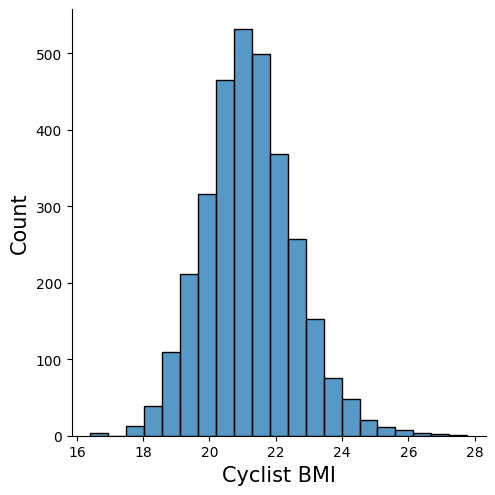

In [5]:
n_bins = math.ceil(math.log2(len(dataset)) + 1)

sb.displot(dataset.drop_duplicates(subset=['cyclist_bmi', 'cyclist_url']), 
                x="cyclist_bmi", 
                kind="hist",
                row_order="desc",
                bins=n_bins)
plt.xlabel('Cyclist BMI', fontsize=15)
plt.ylabel('Count', fontsize=15)

Text(0, 0.5, 'Cyclist Age Group')

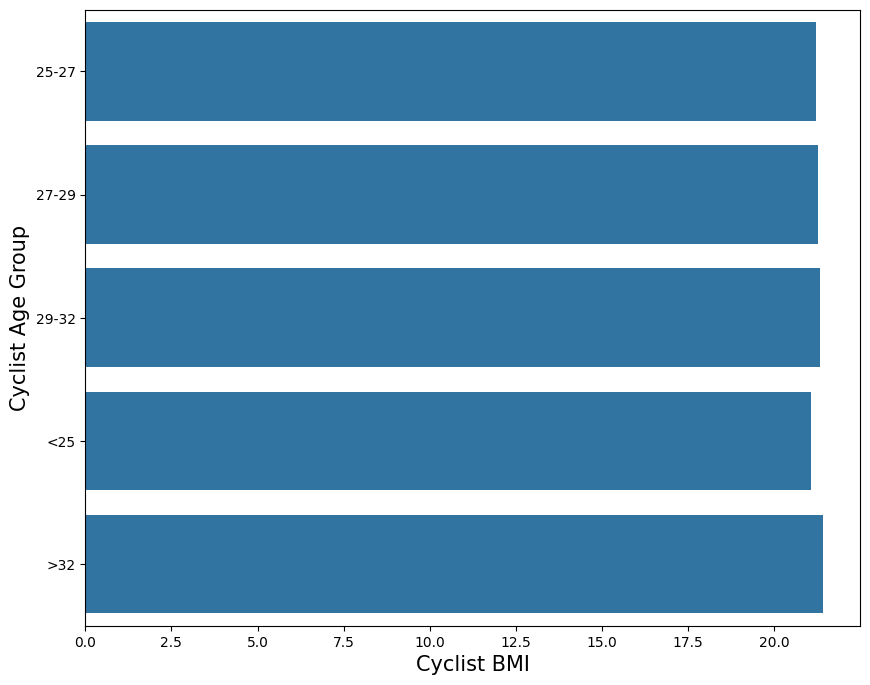

In [6]:
tmp_df = pd.DataFrame({
    'cyclist_age_group': dataset['cyclist_age_group'],
    'cyclist_bmi': dataset['cyclist_bmi'],
    'team': dataset['cyclist_team'],
    'cyclist_url': dataset['cyclist_url'],
    'nationality': dataset['nationality'],
    'race_name': dataset['race_name'],
    'race_prestige': dataset['race_prestige'],
    'year': dataset['date'].dt.year,
}).drop_duplicates(subset=['cyclist_url', 'race_name', 'year']) # Consider every cyclist only once for each edition of the race

tmp_mean = tmp_df.groupby('cyclist_age_group')['cyclist_bmi'].mean().reset_index()

plt.figure(figsize=(10, 8))
sb.barplot(y='cyclist_age_group', x='cyclist_bmi', data=tmp_mean[tmp_mean['cyclist_bmi'].notnull()], orient='h')

plt.xlabel('Cyclist BMI', fontsize=15)
plt.ylabel('Cyclist Age Group', fontsize=15)

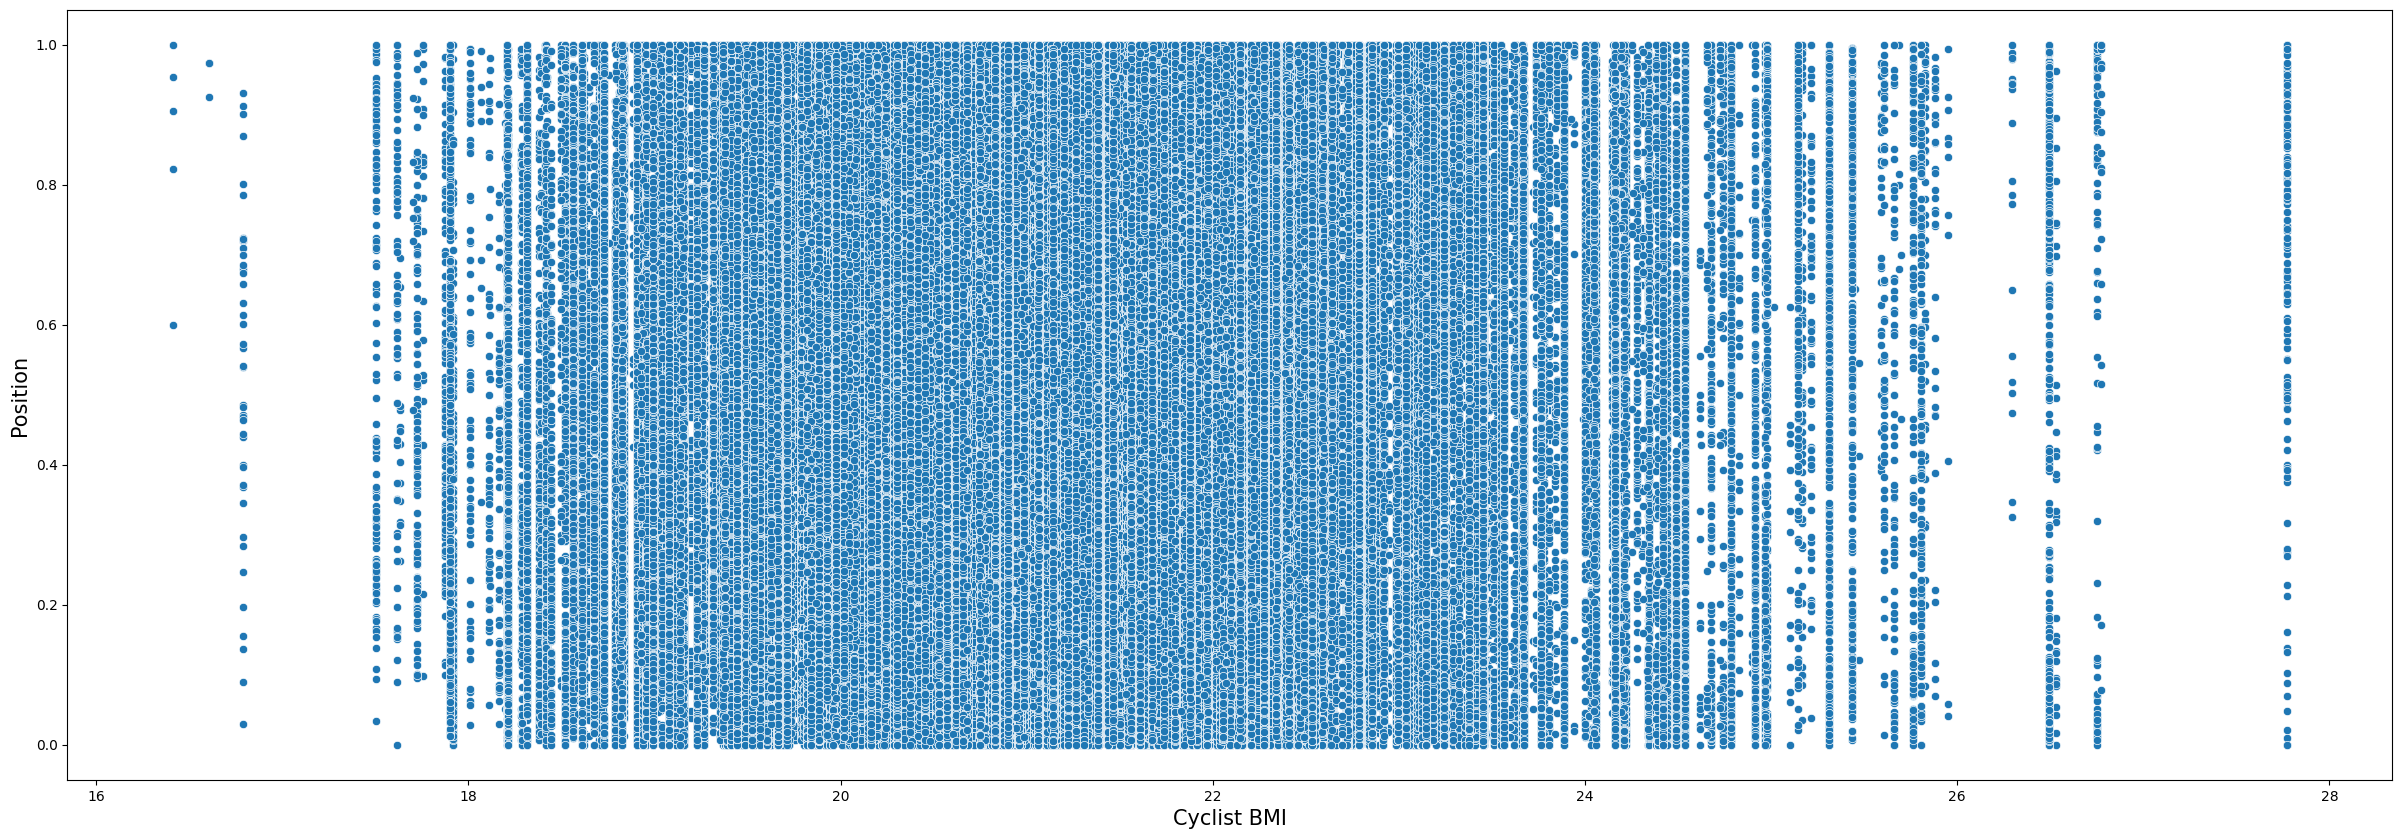

In [7]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_bmi',
    y='position',
    data=dataset)
plt.xlabel('Cyclist BMI', fontsize=15)
plt.ylabel('Position', fontsize=15)
plt.show()

There doesn't appear to be a clear or strong relationship between the variables being analyzed.

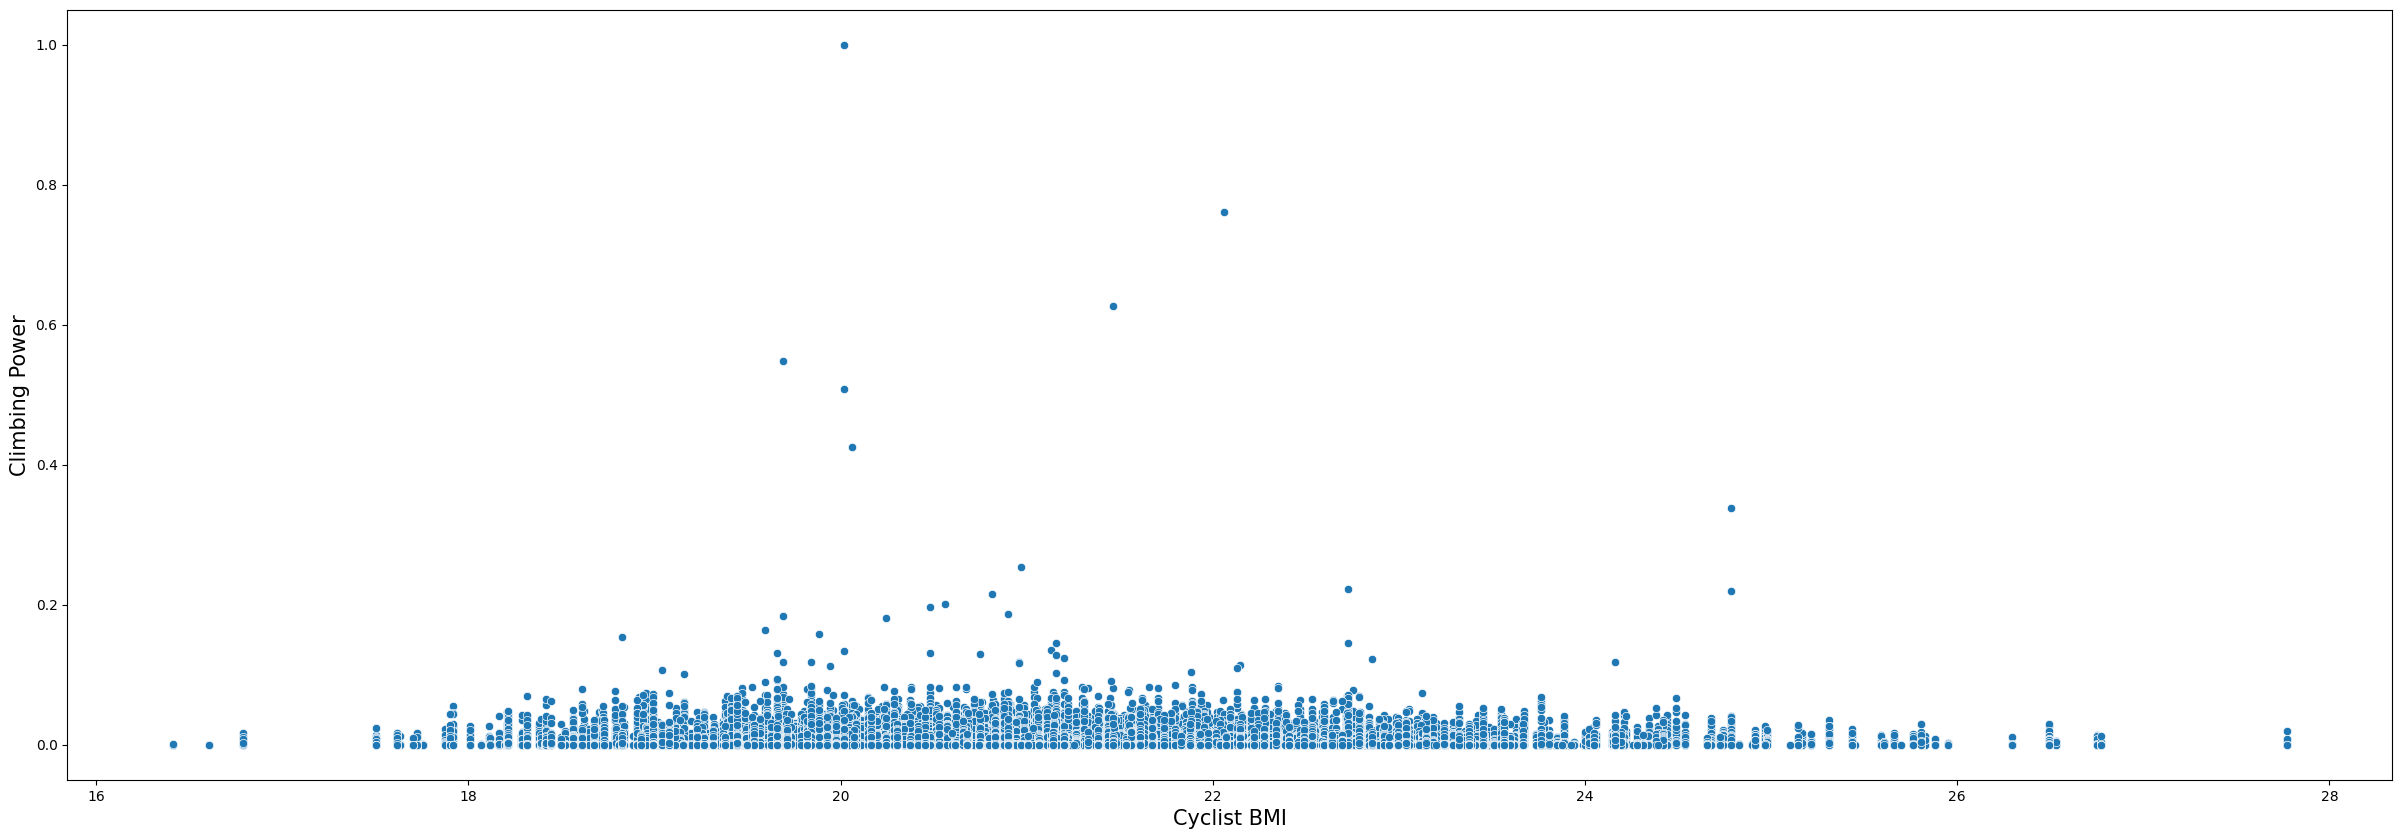

In [8]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_bmi',
    y='cyclist_climb_power',
    data=dataset)
plt.xlabel('Cyclist BMI', fontsize=15)
plt.ylabel('Climbing Power', fontsize=15)
plt.show()

From this distribution we can notice the bell shape, where a medium BMI seems to allow for higher power outputs.

In [9]:
tmp_df.groupby('team')['cyclist_bmi'].describe()

,count,mean,std,min,25%,50%,75%,max
team,,,,,,,,
ag2r-prevoyance-2001,1072.0,21.419181,1.370057,17.617725,20.515086,21.457612,22.205990,25.880571
atala-1985,523.0,21.454217,1.362540,17.915089,20.654142,21.385936,22.160665,26.528510
atala-campagnolo-1983,735.0,21.212145,1.353612,18.206645,20.233553,21.132713,22.145329,25.805363
atala-ofmega-1988,320.0,21.159366,1.229889,18.206645,20.305175,21.144004,22.038401,23.483477
australia-1983,738.0,21.288382,1.370986,17.901235,20.305175,21.200991,22.145329,25.762981
...,...,...,...,...,...,...,...,...
united-states-1998,1010.0,20.982776,1.312672,18.214936,20.134769,20.826851,21.877551,24.828593
ville-de-charleroi-new-systems-2000,1119.0,21.290073,1.254712,18.166204,20.515086,21.203105,21.913580,26.528510
vini-fantini-2013,531.0,21.147115,1.384059,18.209877,20.244898,21.132713,22.038401,26.296567


In [10]:
tmp_df.groupby('nationality')['cyclist_bmi'].describe()

,count,mean,std,min,25%,50%,75%,max
nationality,,,,,,,,
Albania,6.0,23.291230,0.000000,23.291230,23.291230,23.291230,23.291230,23.291230
Algeria,12.0,23.323418,0.000000,23.323418,23.323418,23.323418,23.323418,23.323418
Argentina,133.0,21.347946,1.053120,19.713322,19.713322,21.705129,21.705129,23.456790
Australia,3018.0,21.707712,1.254587,18.559557,20.957274,21.678807,22.530864,24.897060
Austria,1022.0,20.669090,1.086567,18.836565,20.006569,20.338326,21.389756,22.724403
...,...,...,...,...,...,...,...,...
Uruguay,13.0,20.614406,0.353547,20.428357,20.428357,20.428357,20.428357,21.234568
Uzbekistan,51.0,23.288232,1.075557,20.987654,23.781213,23.781213,23.781213,23.781213
Venezuela,103.0,20.316719,1.146805,18.289895,19.591837,20.756387,20.756387,24.163265


### Age-Group Attribute

Text(-12.430555555555555, 0.5, 'Count')

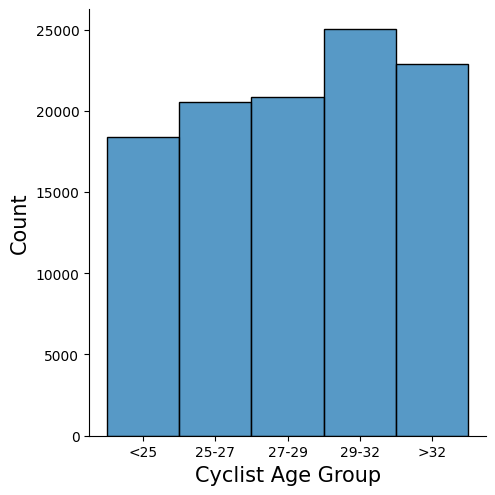

In [11]:
n_bins = dataset['cyclist_age_group'].nunique()

sb.displot(dataset[['cyclist_url', 'race_name', 'race_year', 'cyclist_age_group']].drop_duplicates(subset=['cyclist_url', 'race_name', 'race_year']), 
                x="cyclist_age_group", 
                kind="hist",
                row_order="desc",
                bins=n_bins)
plt.xlabel('Cyclist Age Group', fontsize=15)
plt.ylabel('Count', fontsize=15)

In [12]:
dataset.groupby('cyclist_age_group')['position'].describe()

,count,mean,std,min,25%,50%,75%,max
cyclist_age_group,,,,,,,,
25-27,112242.0,0.504367,0.296338,0.0,0.243386,0.507692,0.765349,1.0
27-29,115093.0,0.490425,0.294065,0.0,0.232258,0.484694,0.746193,1.0
29-32,140295.0,0.485822,0.289610,0.0,0.235294,0.479290,0.734177,1.0
<25,91500.0,0.530404,0.294949,0.0,0.275862,0.545977,0.790541,1.0
>32,130608.0,0.498432,0.282108,0.0,0.260355,0.497175,0.736842,1.0


In general, older is better, with the best age group being 29-32.

In [13]:
tmp_df = dataset.drop_duplicates(subset=['race_name', 'race_year', 'cyclist_url'])
pd.crosstab(tmp_df['cyclist_age_group'], tmp_df['race_season'], normalize='index')

race_season,autumn,spring,summer,winter
cyclist_age_group,,,,
25-27,0.044070,0.464925,0.207478,0.283528
27-29,0.039927,0.460480,0.213440,0.286153
29-32,0.041513,0.458847,0.211166,0.288474
<25,0.052540,0.467965,0.197542,0.281954
>32,0.039258,0.450479,0.196901,0.313362


We can say that the youngest age group is more frequent in autumn and spring periods, while the middle age groups (27-29, 29-32) are most frequent in summer. The oldest age group (> 32) is most frequent in winter.

Text(0, 0.5, 'Startlist Quality')

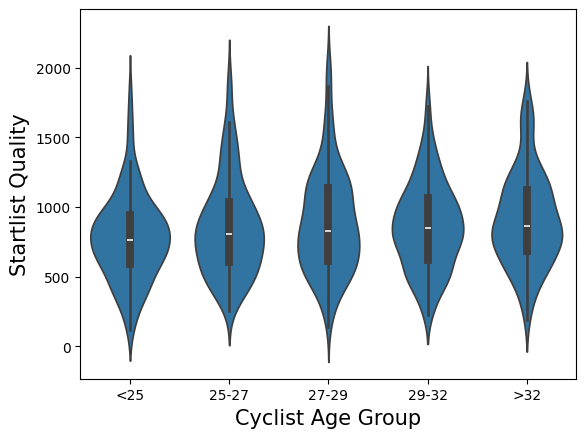

In [56]:
sb.violinplot(
    data=tmp_df,
    x='cyclist_age_group',
    y='startlist_quality')
plt.xlabel('Cyclist Age Group', fontsize=15)
plt.ylabel('Startlist Quality', fontsize=15)

In [15]:
tmp_df.groupby('cyclist_age_group')['startlist_quality'].describe()

,count,mean,std,min,25%,50%,75%,max
cyclist_age_group,,,,,,,,
25-27,20513.0,960.108663,340.406777,115.0,737.0,917.0,1148.0,2047.0
27-29,20863.0,975.901165,338.638341,115.0,754.0,928.0,1158.0,2047.0
29-32,25004.0,987.272636,329.682274,115.0,766.0,943.0,1165.0,2047.0
<25,18386.0,909.591755,319.022402,115.0,704.0,869.0,1084.0,2047.0
>32,22849.0,975.534465,314.205485,115.0,764.0,935.0,1140.0,2047.0


The trend of the startlist quality seems to be correlated with the increase in age up to the 29-32 age group, after which it appears to decline.

Text(0, 0.5, 'Points')

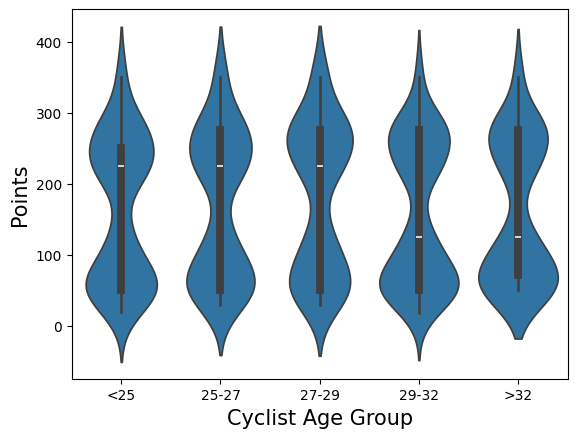

In [57]:
sb.violinplot(
    data=tmp_df,
    x='cyclist_age_group',
    y='points')
plt.xlabel('Cyclist Age Group', fontsize=15)
plt.ylabel('Points', fontsize=15)

In [17]:
tmp_df.groupby('cyclist_age_group')['points'].describe()

,count,mean,std,min,25%,50%,75%,max
cyclist_age_group,,,,,,,,
25-27,20513.0,151.707259,98.734522,18.0,50.0,100.0,225.0,350.0
27-29,20863.0,150.562048,98.781073,18.0,50.0,100.0,225.0,350.0
29-32,25004.0,152.082547,99.129032,18.0,50.0,100.0,275.0,350.0
<25,18386.0,151.432557,98.645674,18.0,50.0,100.0,225.0,350.0
>32,22849.0,148.806731,98.618328,18.0,50.0,100.0,225.0,350.0


There doesn't seem to be a strong correlation between the points associated with the races and the age of the cyclists, which further proves that the points are not linked with the startlist quality.

Text(0, 0.5, 'Race Prestige')

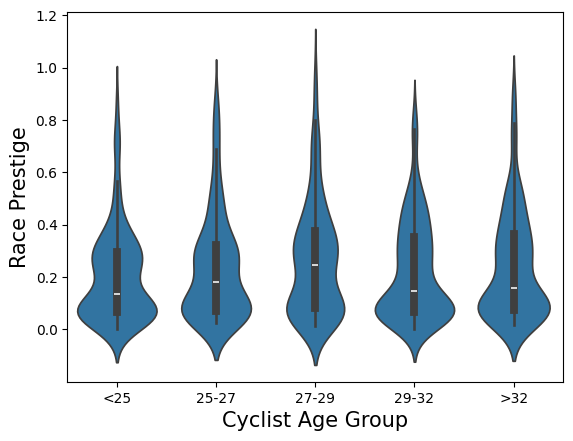

In [58]:
sb.violinplot(
    data=tmp_df,
    x='cyclist_age_group',
    y='race_prestige')
plt.xlabel('Cyclist Age Group', fontsize=15)
plt.ylabel('Race Prestige', fontsize=15)

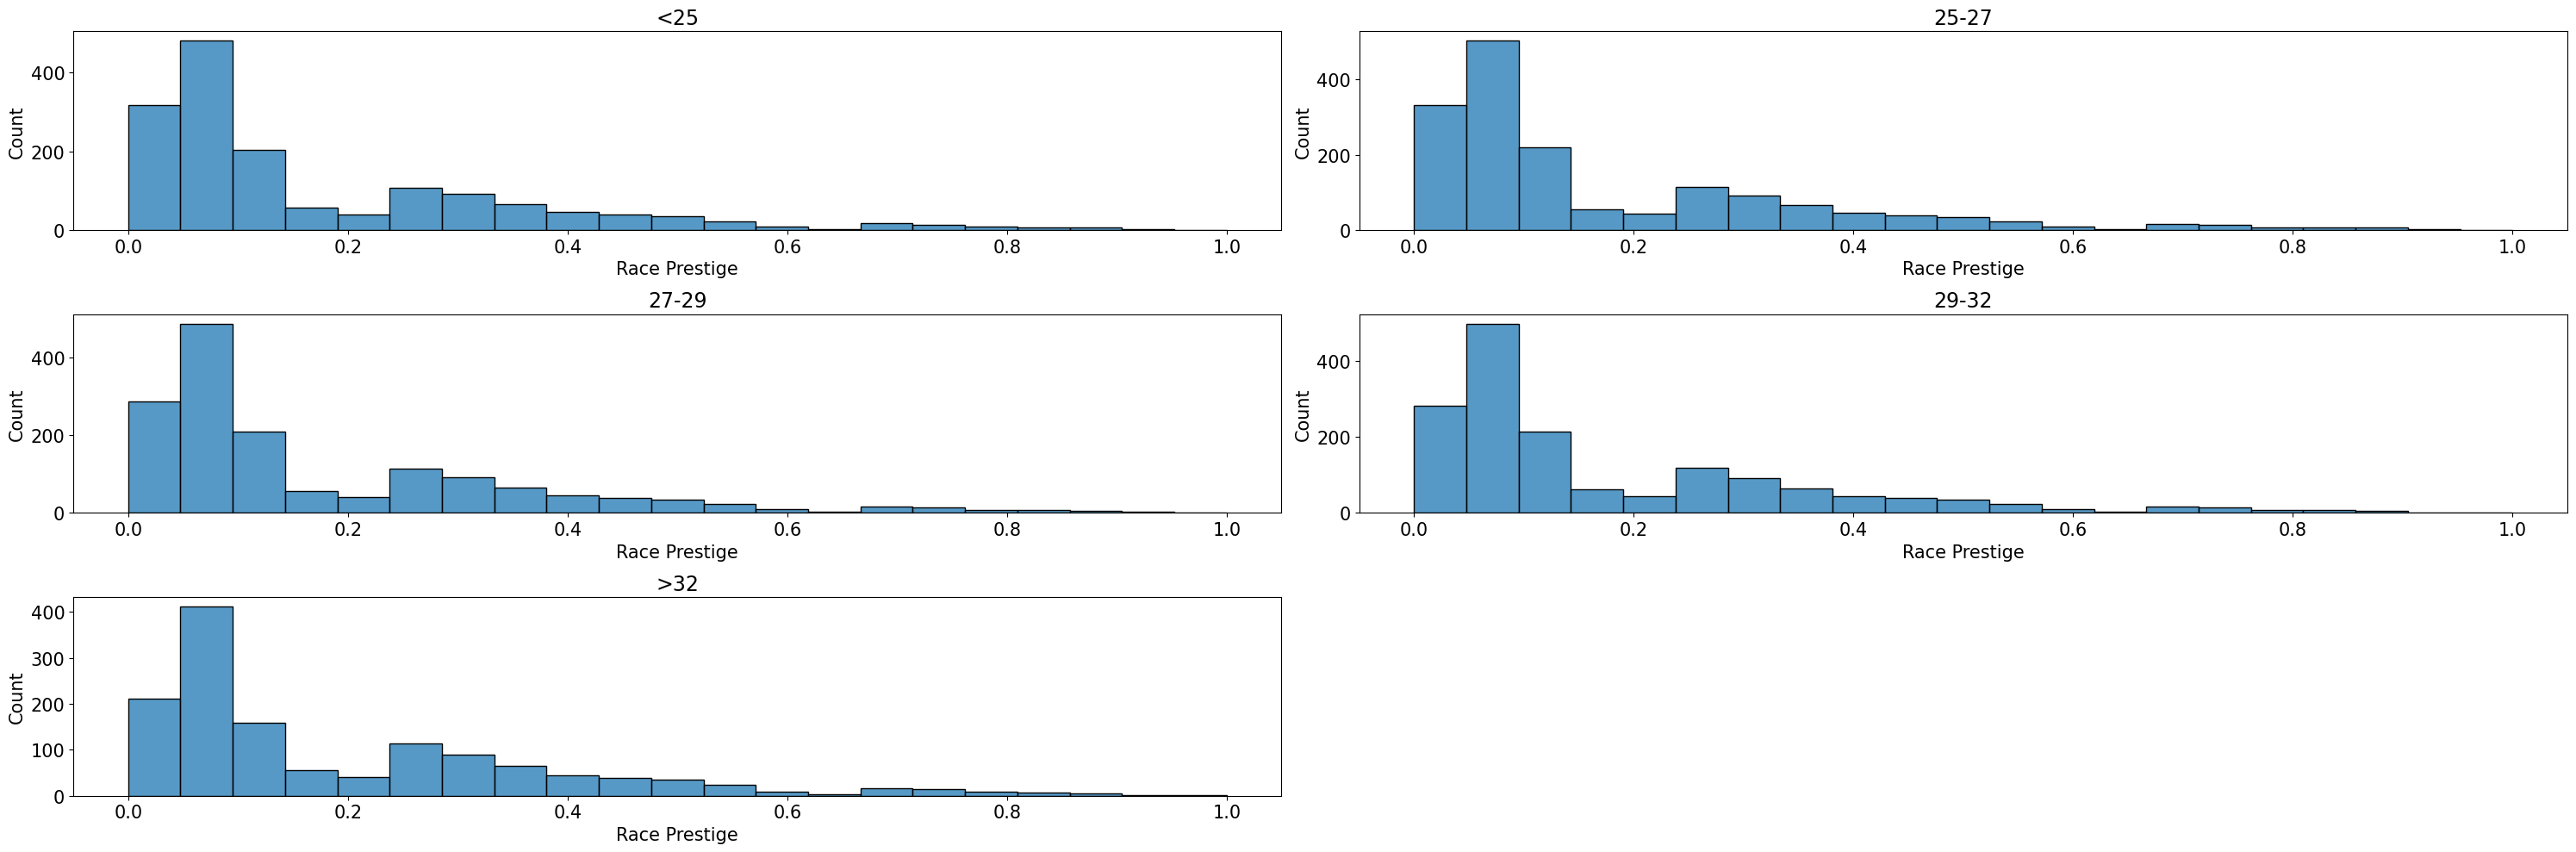

In [19]:
n_bins = math.ceil(math.log2(len(dataset)) + 1)
fig, ax = plt.subplots(3, 2, figsize=(30, 10))

sb.histplot(tmp_df[tmp_df['cyclist_age_group'] == '<25'].drop_duplicates(subset=['race_name', 'race_stage', 'race_year']), 
            x="race_prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[0, 0])
ax[0,0].set_title('<25', fontsize=17)
ax[0,0].set_xlabel('Race Prestige', fontsize=15)
ax[0,0].set_ylabel('Count', fontsize=15)
ax[0,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['cyclist_age_group'] == '25-27'].drop_duplicates(subset=['race_name', 'race_stage', 'race_year']), 
            x="race_prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[0, 1]) 
ax[0,1].set_title('25-27', fontsize=17)
ax[0,1].set_xlabel('Race Prestige', fontsize=15)
ax[0,1].set_ylabel('Count', fontsize=15)
ax[0,1].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['cyclist_age_group'] == '27-29'].drop_duplicates(subset=['race_name', 'race_stage', 'race_year']), 
            x="race_prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[1, 0]) 
ax[1,0].set_title('27-29', fontsize=17)
ax[1,0].set_xlabel('Race Prestige', fontsize=15)
ax[1,0].set_ylabel('Count', fontsize=15)
ax[1,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['cyclist_age_group'] == '29-32'].drop_duplicates(subset=['race_name', 'race_stage', 'race_year']), 
            x="race_prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[1, 1])
ax[1,1].set_title('29-32', fontsize=17)
ax[1,1].set_xlabel('Race Prestige', fontsize=15)
ax[1,1].set_ylabel('Count', fontsize=15)
ax[1,1].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['cyclist_age_group'] == '>32'].drop_duplicates(subset=['race_name', 'race_stage', 'race_year']), 
            x="race_prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[2, 0])
ax[2,0].set_title('>32', fontsize=17) 
ax[2,0].set_xlabel('Race Prestige', fontsize=15)
ax[2,0].set_ylabel('Count', fontsize=15)
ax[2,0].tick_params(axis='both', which='major', labelsize=15)

fig.delaxes(ax[2, 1]) # Remove empty subplot

plt.tight_layout()
plt.show()

In [20]:
pd.crosstab(tmp_df['cyclist_team'], tmp_df['cyclist_age_group'], normalize='index')

cyclist_age_group,25-27,27-29,29-32,<25,>32
cyclist_team,,,,,
ag2r-prevoyance-2001,0.200158,0.148148,0.234043,0.171789,0.245863
atala-1985,0.239370,0.152756,0.253543,0.179528,0.174803
atala-campagnolo-1983,0.159236,0.235669,0.189809,0.191083,0.224204
atala-ofmega-1988,0.143302,0.224299,0.242991,0.183801,0.205607
australia-1983,0.203797,0.163291,0.212658,0.165823,0.254430
...,...,...,...,...,...
united-states-1998,0.173561,0.164568,0.239209,0.188849,0.233813
ville-de-charleroi-new-systems-2000,0.164965,0.201100,0.277298,0.136685,0.219953
vini-fantini-2013,0.245283,0.231132,0.215409,0.165094,0.143082


### Climb-Power Attribute

Text(-12.430555555555555, 0.5, 'Count')

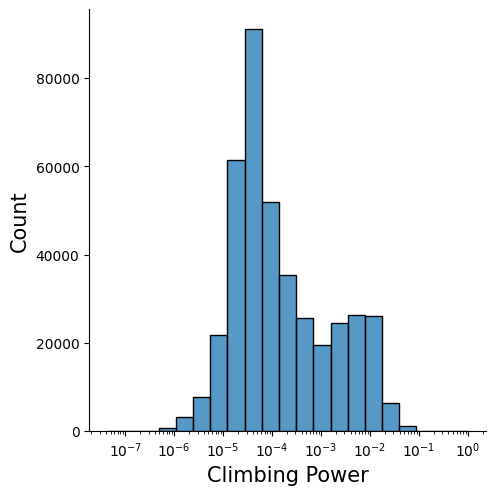

In [21]:
n_bins = math.ceil(math.log2(len(dataset)) + 1)

sb.displot(dataset.drop_duplicates(subset=['cyclist_climb_power', 'cyclist_url', 'date']), 
                x="cyclist_climb_power", 
                kind="hist",
                row_order="desc",
                bins=n_bins, 
                log_scale=True)
plt.xlabel('Climbing Power', fontsize=15)
plt.ylabel('Count', fontsize=15)

Text(0, 0.5, 'Cyclist Age Group')

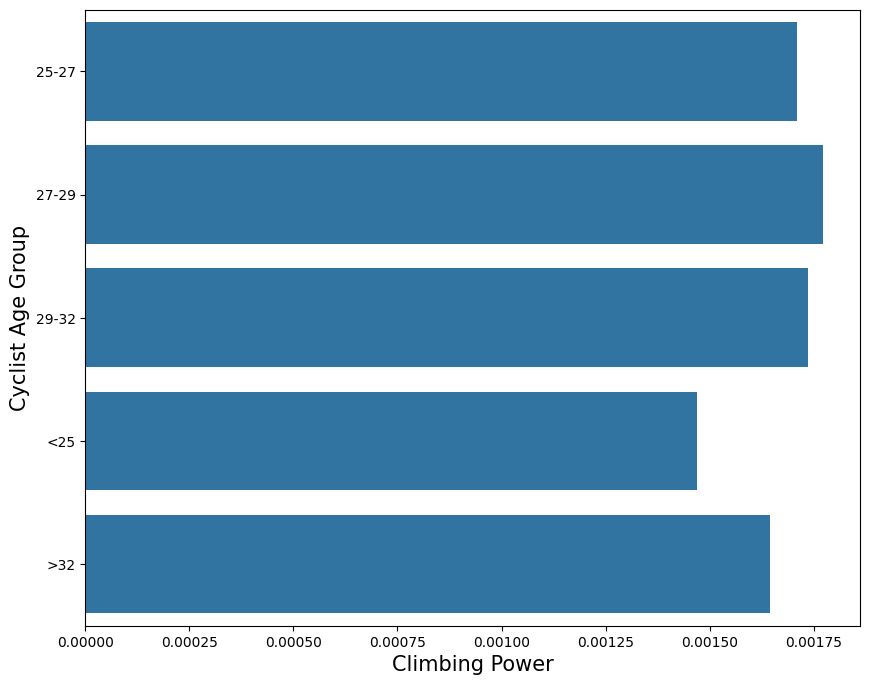

In [22]:
tmp_df = pd.DataFrame({
    'cyclist_age_group': dataset[dataset['profile'] > 2]['cyclist_age_group'],
    'cyclist_climb_power': dataset[dataset['profile'] > 2]['cyclist_climb_power'],
})

tmp_mean = tmp_df.groupby('cyclist_age_group')['cyclist_climb_power'].mean().reset_index()

plt.figure(figsize=(10, 8))
sb.barplot(
    y='cyclist_age_group',
    x='cyclist_climb_power',
    data=tmp_mean[tmp_mean['cyclist_climb_power'].notnull()],
    orient='h')
plt.xlabel('Climbing Power', fontsize=15)
plt.ylabel('Cyclist Age Group', fontsize=15)

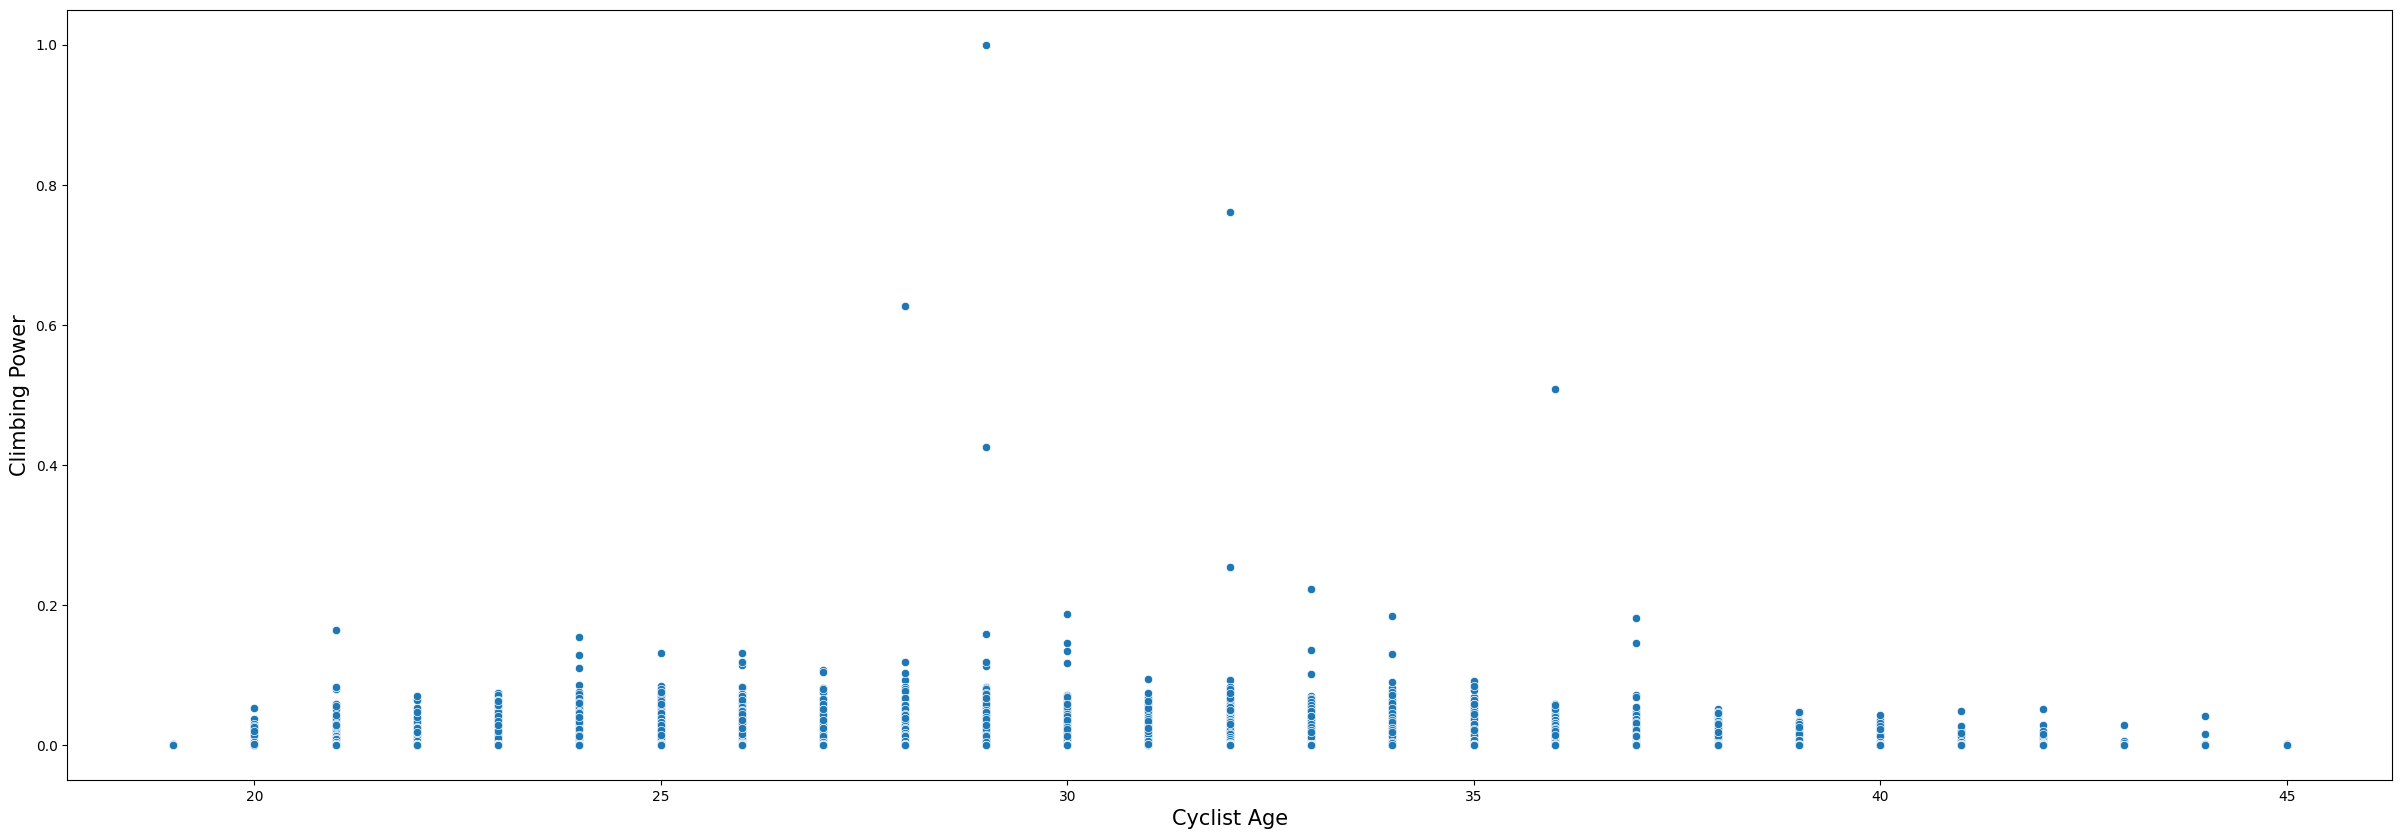

In [23]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_age',
    y='cyclist_climb_power',
    data=dataset[dataset['profile'] > 2])
plt.xlabel('Cyclist Age', fontsize=15)
plt.ylabel('Climbing Power', fontsize=15)
plt.show()

The trend of points distribution shows an initial increase, reaching a peak, and then a subsequent decrease. This pattern suggests that there is a certain range where the points are maximized before declining again.

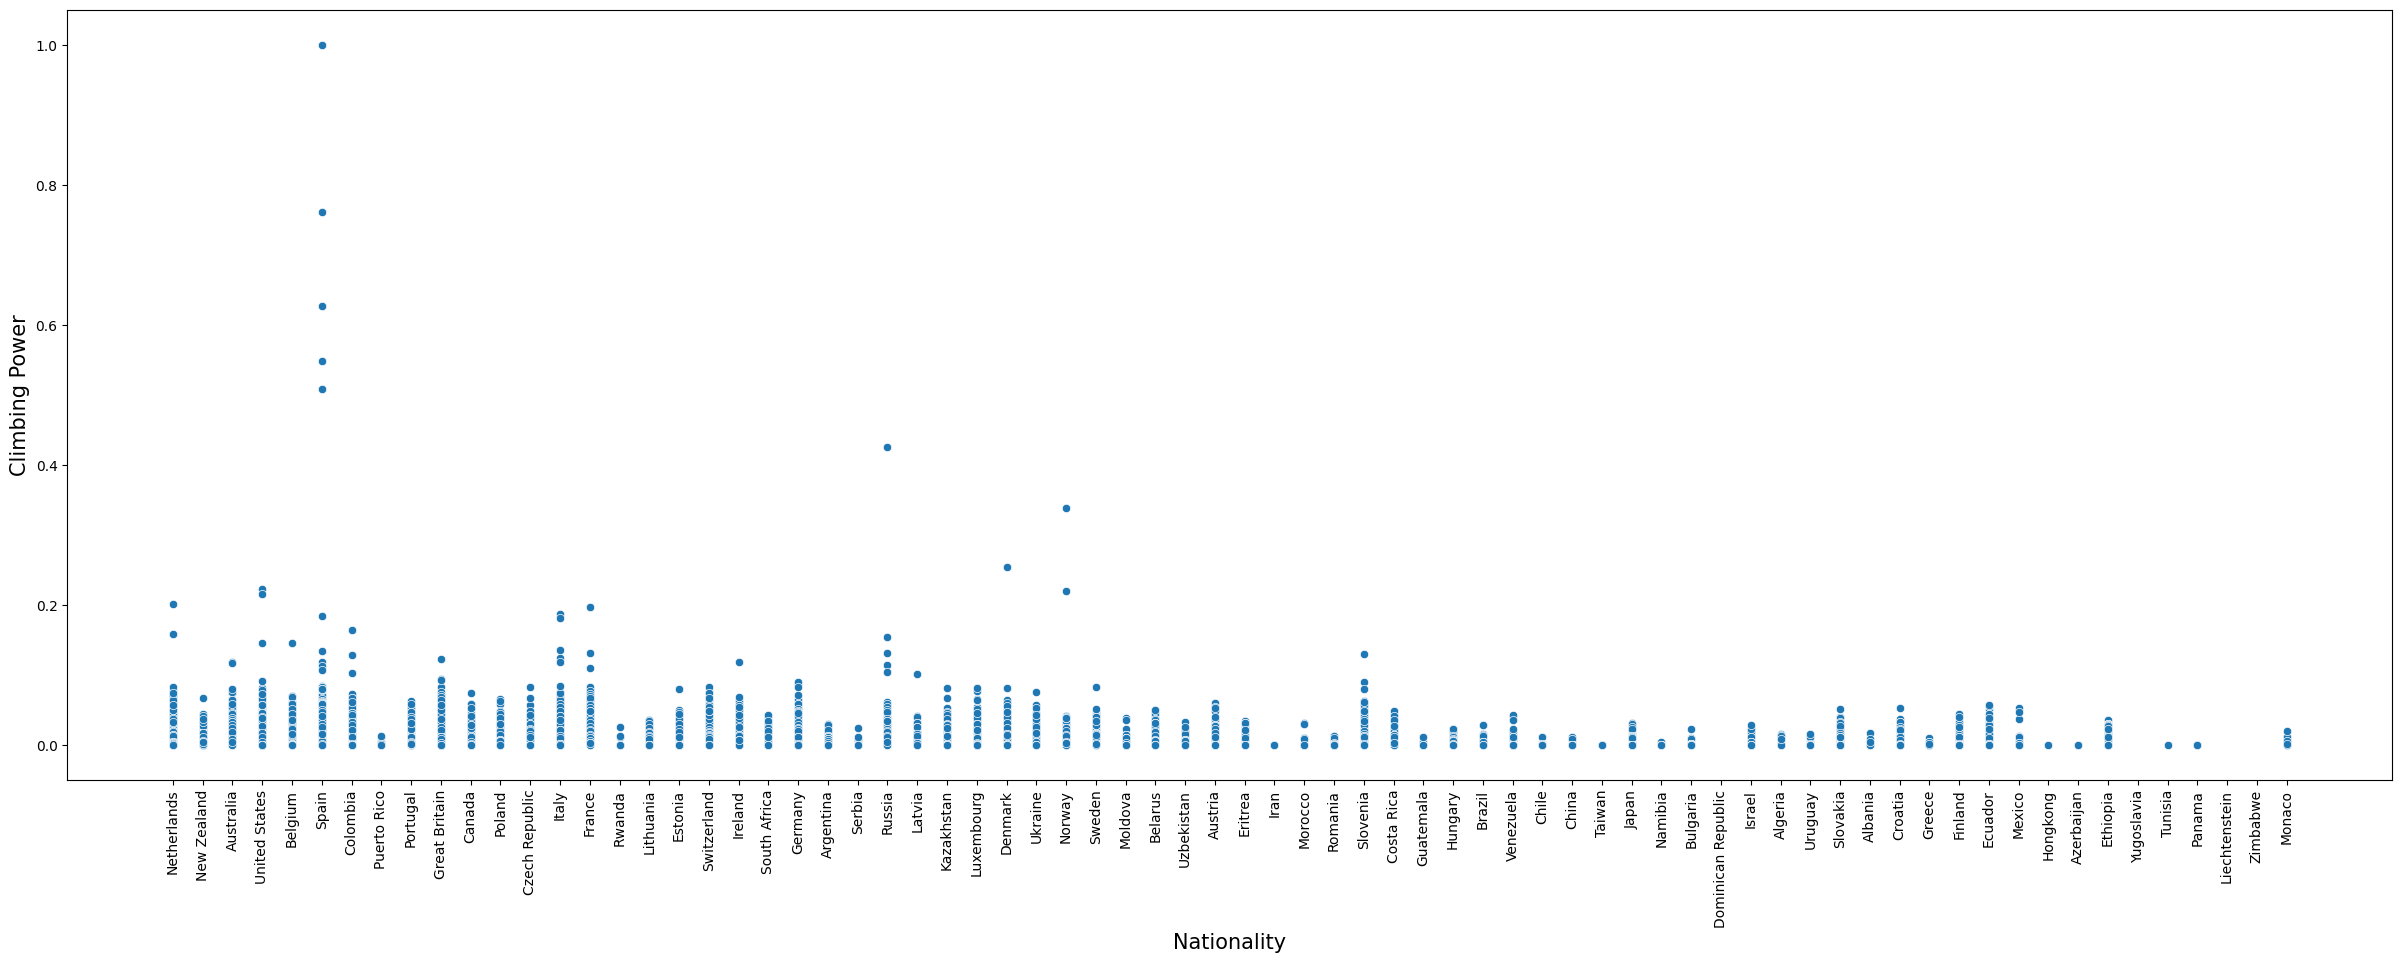

In [24]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='nationality',
    y='cyclist_climb_power',
    data=dataset)
plt.xticks(rotation=90)
plt.xlabel('Nationality', fontsize=15)
plt.ylabel('Climbing Power', fontsize=15)
plt.show()

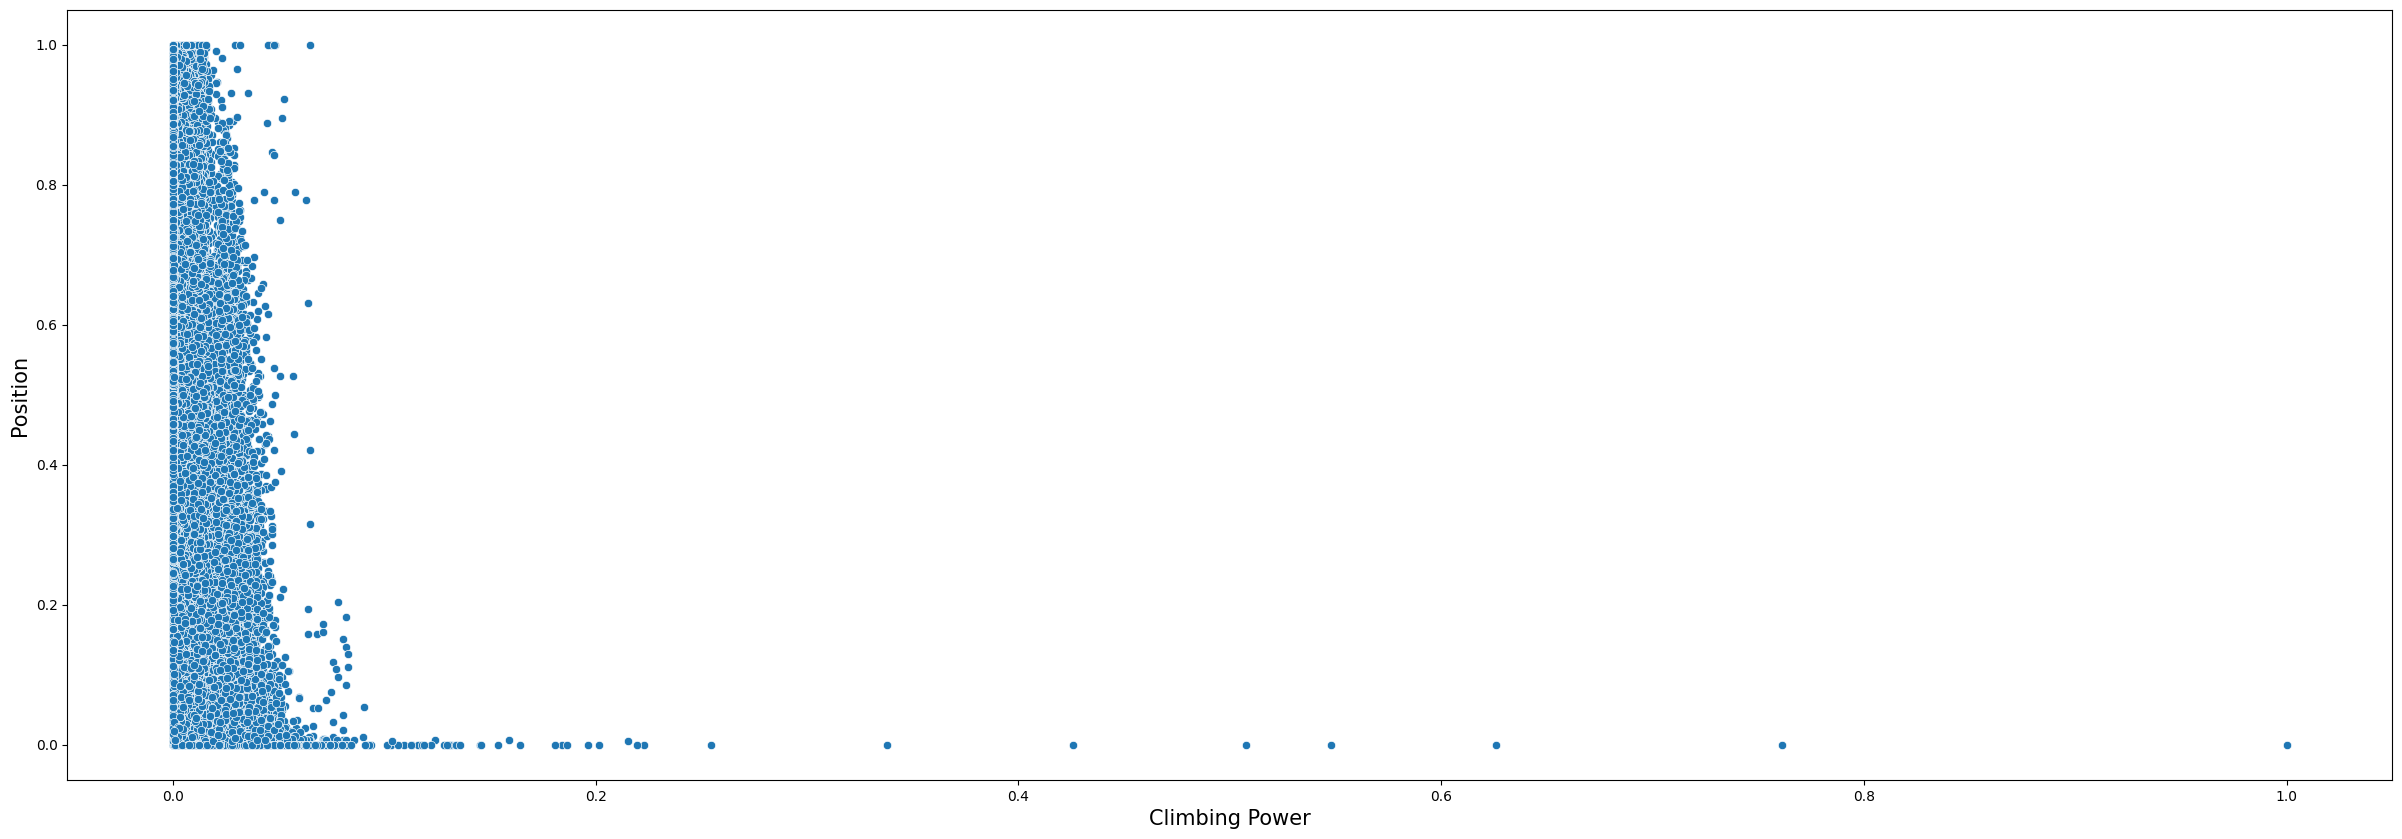

In [25]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_climb_power',
    y='position',
    data=dataset)
plt.xlabel('Climbing Power', fontsize=15)
plt.ylabel('Position', fontsize=15)
plt.show()

We have a low climb power on flat

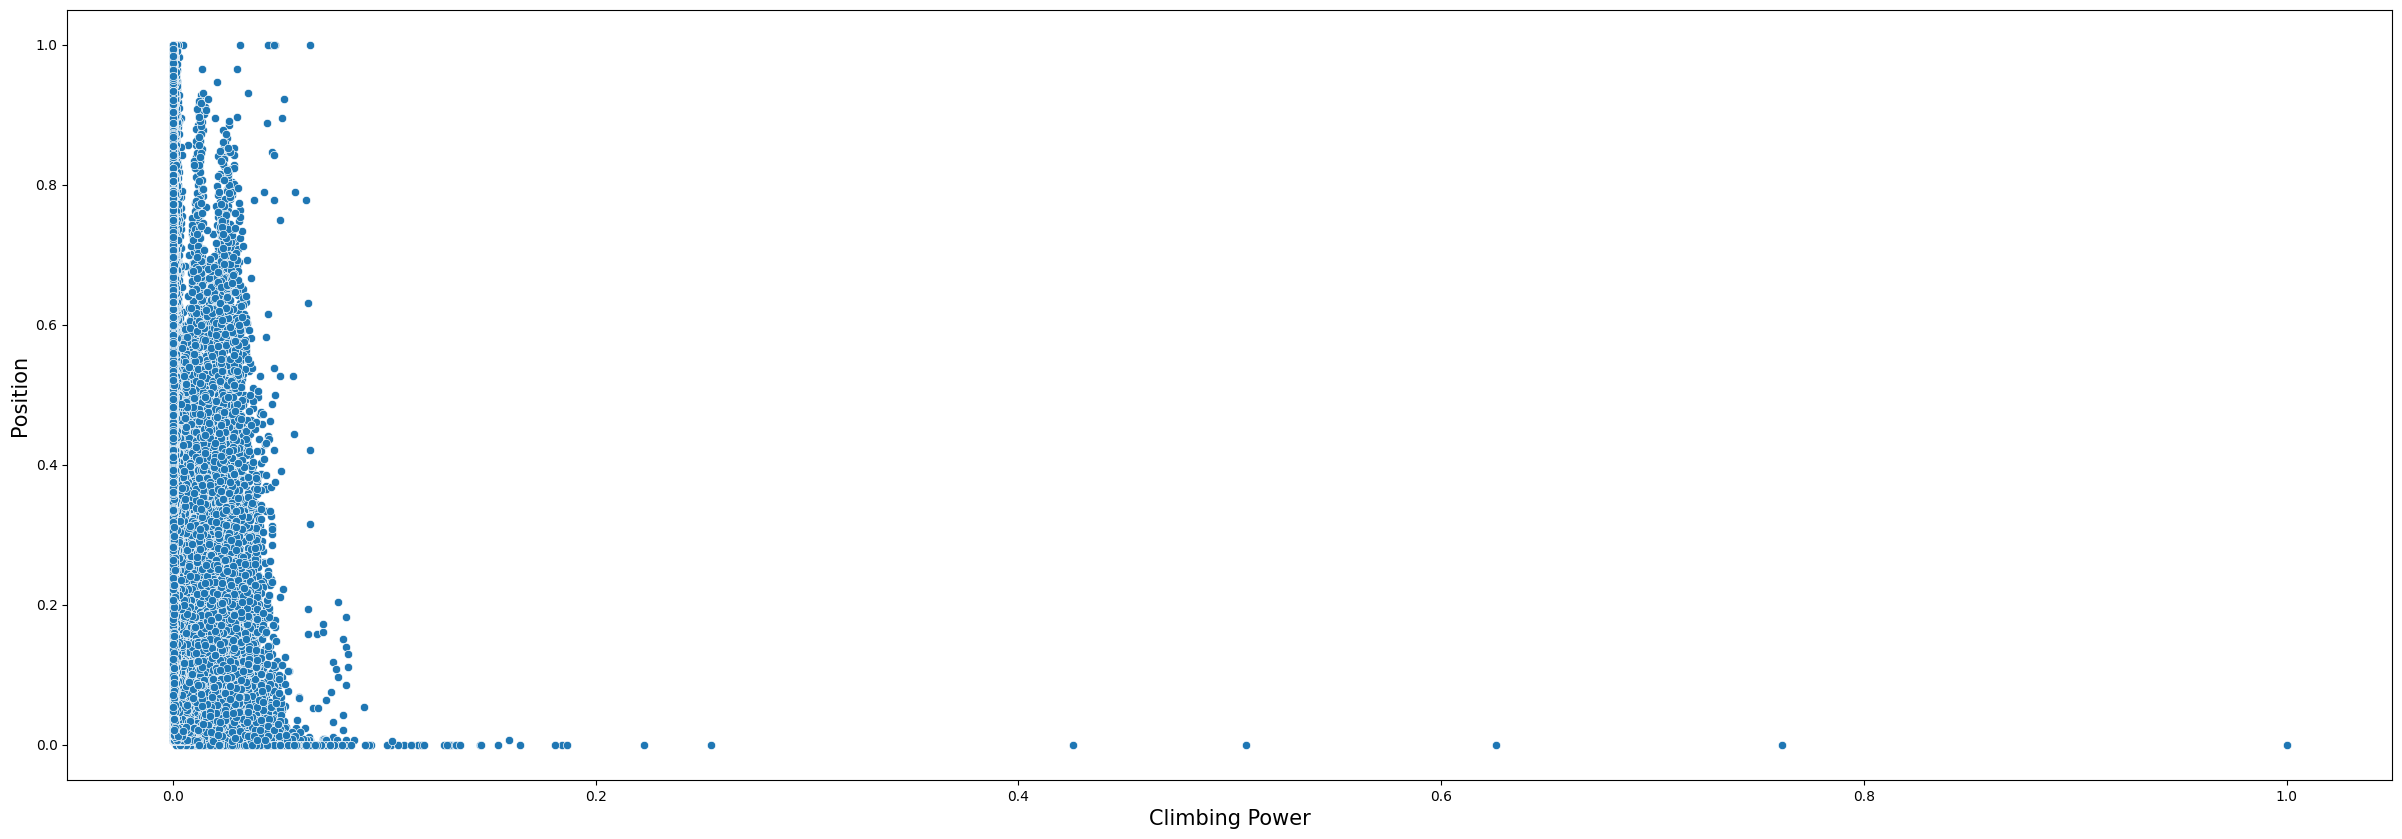

In [26]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_climb_power',
    y='position',
    data=dataset[dataset['profile'] > 2])
plt.xlabel('Climbing Power', fontsize=15)
plt.ylabel('Position', fontsize=15)
plt.show()

### Season Attribute

Text(5.069444444444445, 0.5, 'Count')

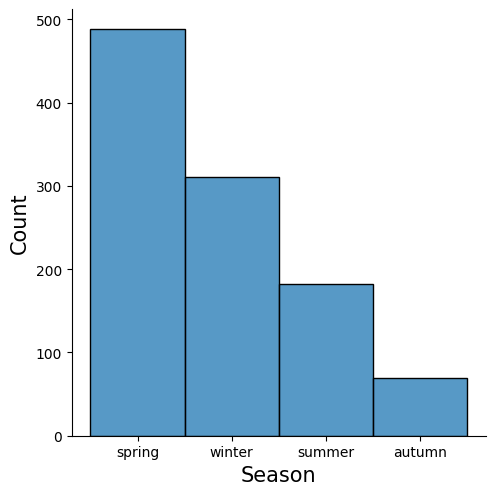

In [27]:
tmp_df = pd.DataFrame({
    'season': dataset['race_season'],
    'prestige': dataset['race_prestige'],
    'race_name': dataset['race_name'],
    'stage': dataset['race_stage'],
    'cyclist_climb_power': dataset['cyclist_climb_power'],
    'team': dataset['cyclist_team'],
    'length': dataset['length'],
    'climb_percentage': dataset['climb_percentage'], 
    'profile': dataset['profile'],
    'bmi': dataset['cyclist_bmi'],
    'year': dataset['date'].dt.year,
})

n_bins = 4

sb.displot(tmp_df.drop_duplicates(subset=['race_name', 'year']), 
                x="season", 
                kind="hist",
                row_order="desc",
                bins=n_bins, 
                log_scale=True)
plt.xlabel('Season', fontsize=15)
plt.ylabel('Count', fontsize=15)

Text(0, 0.5, 'Season')

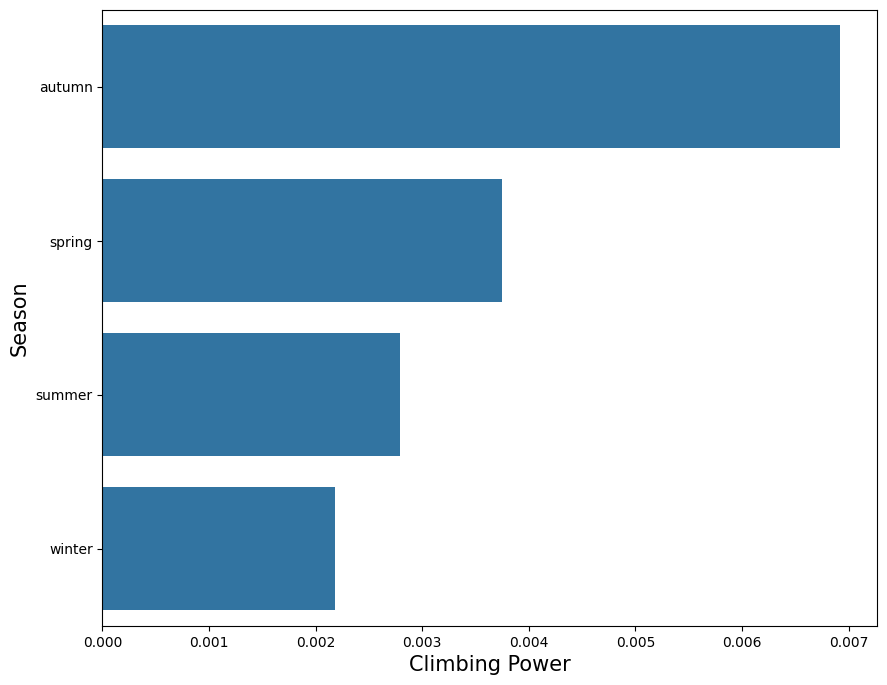

In [28]:
tmp_mean = tmp_df[tmp_df['profile'] > 2].drop_duplicates(subset=['race_name', 'year']).groupby('season')['cyclist_climb_power'].mean().reset_index()
# We avoid profile in {1,2} because they represent flat races
plt.figure(figsize=(10, 8))
sb.barplot(
    y='season',
    x='cyclist_climb_power',
    data=tmp_mean[tmp_mean['cyclist_climb_power'].notnull()],
    orient='h')
plt.xlabel('Climbing Power', fontsize=15)
plt.ylabel('Season', fontsize=15)

Text(0, 0.5, 'Season')

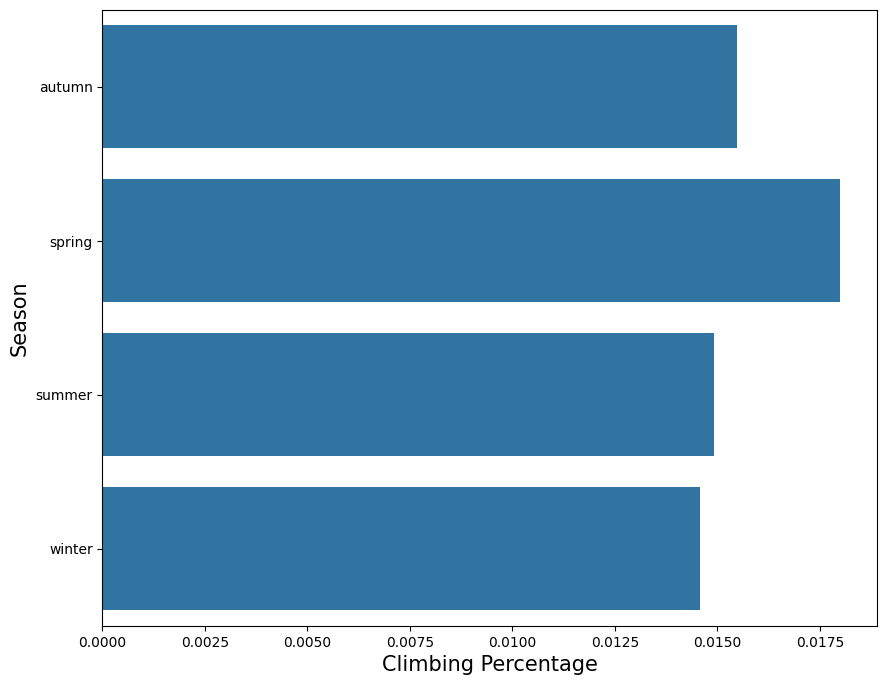

In [29]:
tmp_mean = tmp_df.drop_duplicates(subset=['race_name', 'year', 'stage']).groupby('season')['climb_percentage'].mean().reset_index()
# Filter races with little climb_total and profile
plt.figure(figsize=(10, 8))
sb.barplot(
    y='season',
    x='climb_percentage',
    data=tmp_mean[tmp_mean['climb_percentage'].notnull()],
    orient='h')
plt.xlabel('Climbing Percentage', fontsize=15)
plt.ylabel('Season', fontsize=15)

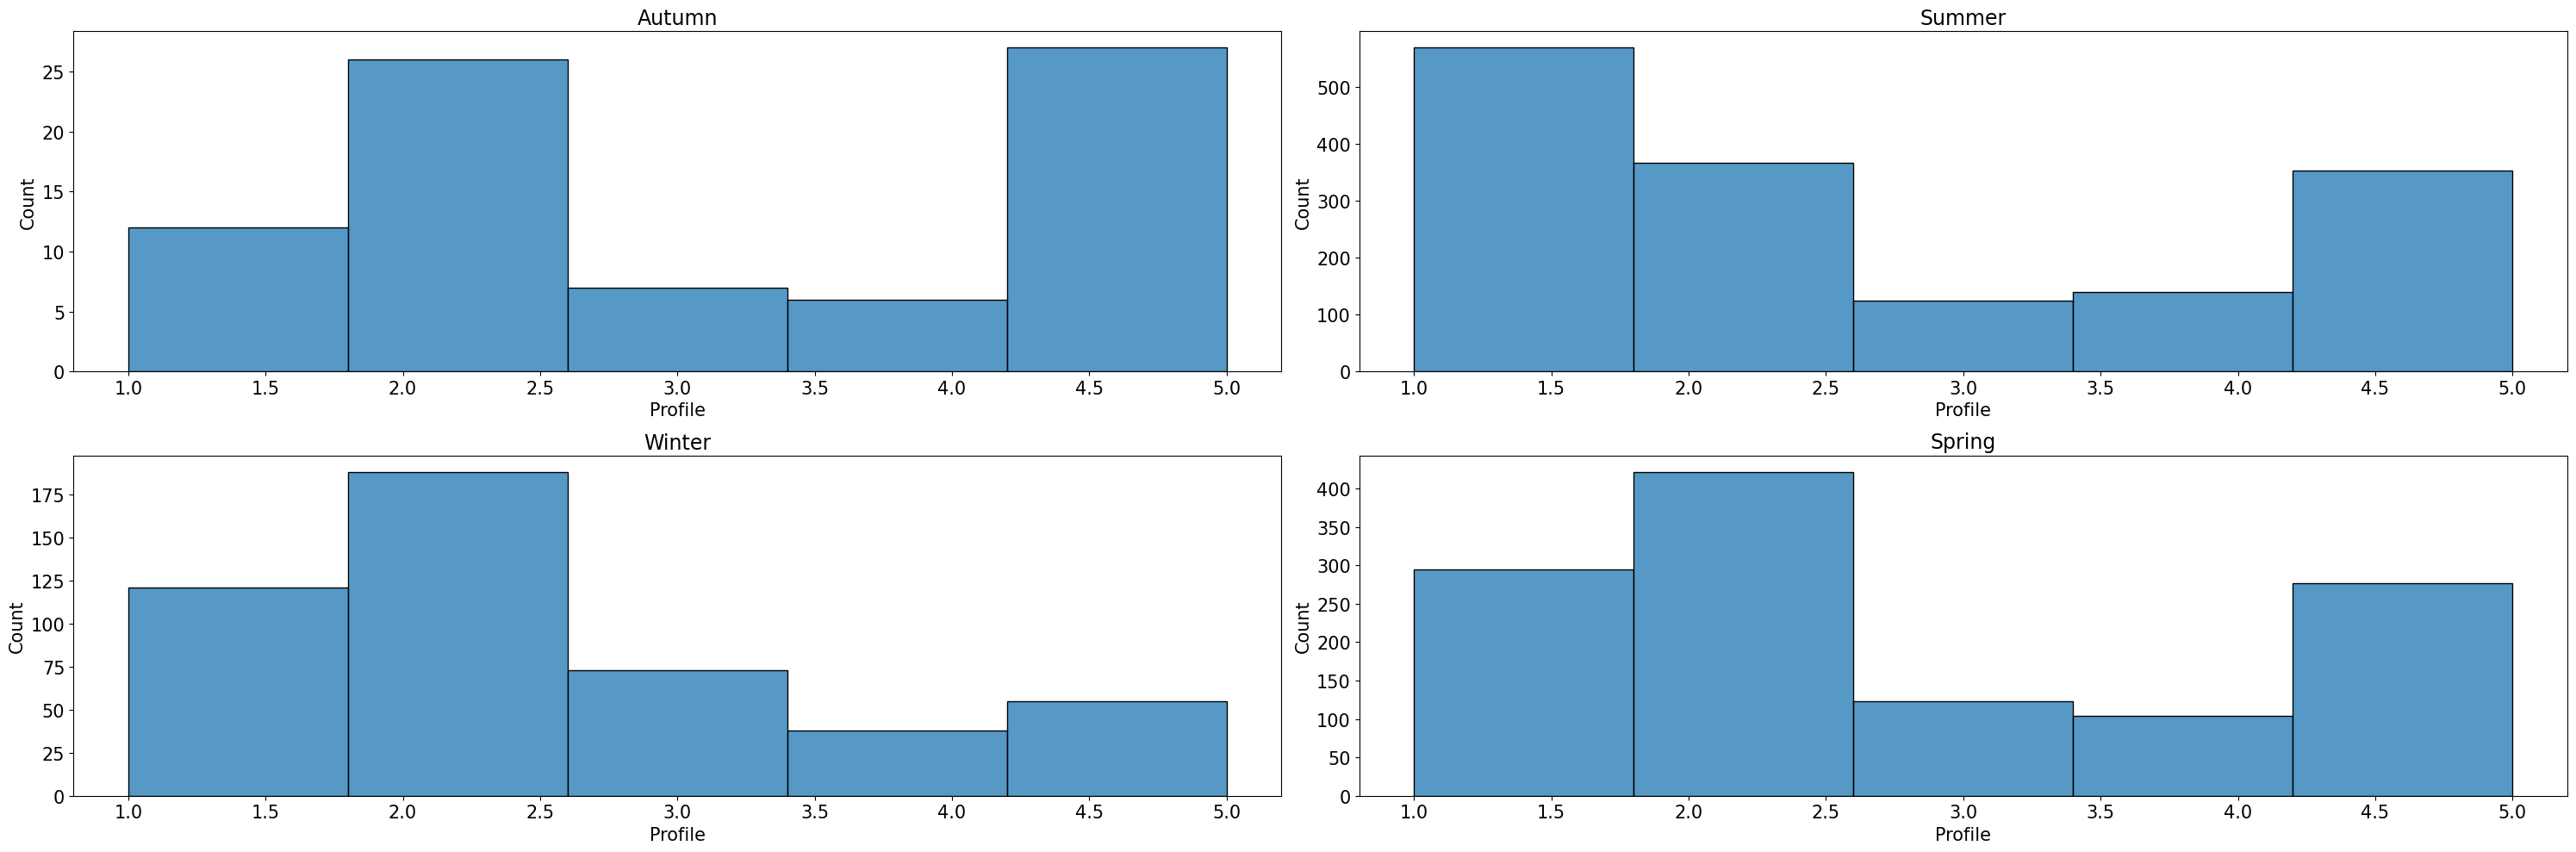

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(30, 10))

sb.histplot(tmp_df[tmp_df['season'] == 'autumn'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="profile", 
            bins=5, 
            log_scale=False, 
            ax=ax[0, 0])
ax[0,0].set_title('Autumn', fontsize=17)
ax[0,0].set_xlabel('Profile', fontsize=15)
ax[0,0].set_ylabel('Count', fontsize=15)
ax[0,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'summer'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="profile", 
            bins=5, 
            log_scale=False, 
            ax=ax[0, 1]) 
ax[0,1].set_title('Summer', fontsize=17)
ax[0,1].set_xlabel('Profile', fontsize=15)
ax[0,1].set_ylabel('Count', fontsize=15)
ax[0,1].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'winter'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="profile", 
            bins=5, 
            log_scale=False, 
            ax=ax[1, 0]) 
ax[1,0].set_title('Winter', fontsize=17)
ax[1,0].set_xlabel('Profile', fontsize=15)
ax[1,0].set_ylabel('Count', fontsize=15)
ax[1,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'spring'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="profile", 
            bins=5, 
            log_scale=False, 
            ax=ax[1, 1])
ax[1,1].set_title('Spring', fontsize=17)
ax[1,1].set_xlabel('Profile', fontsize=15)
ax[1,1].set_ylabel('Count', fontsize=15)
ax[1,1].tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout() # Avoid overlapping

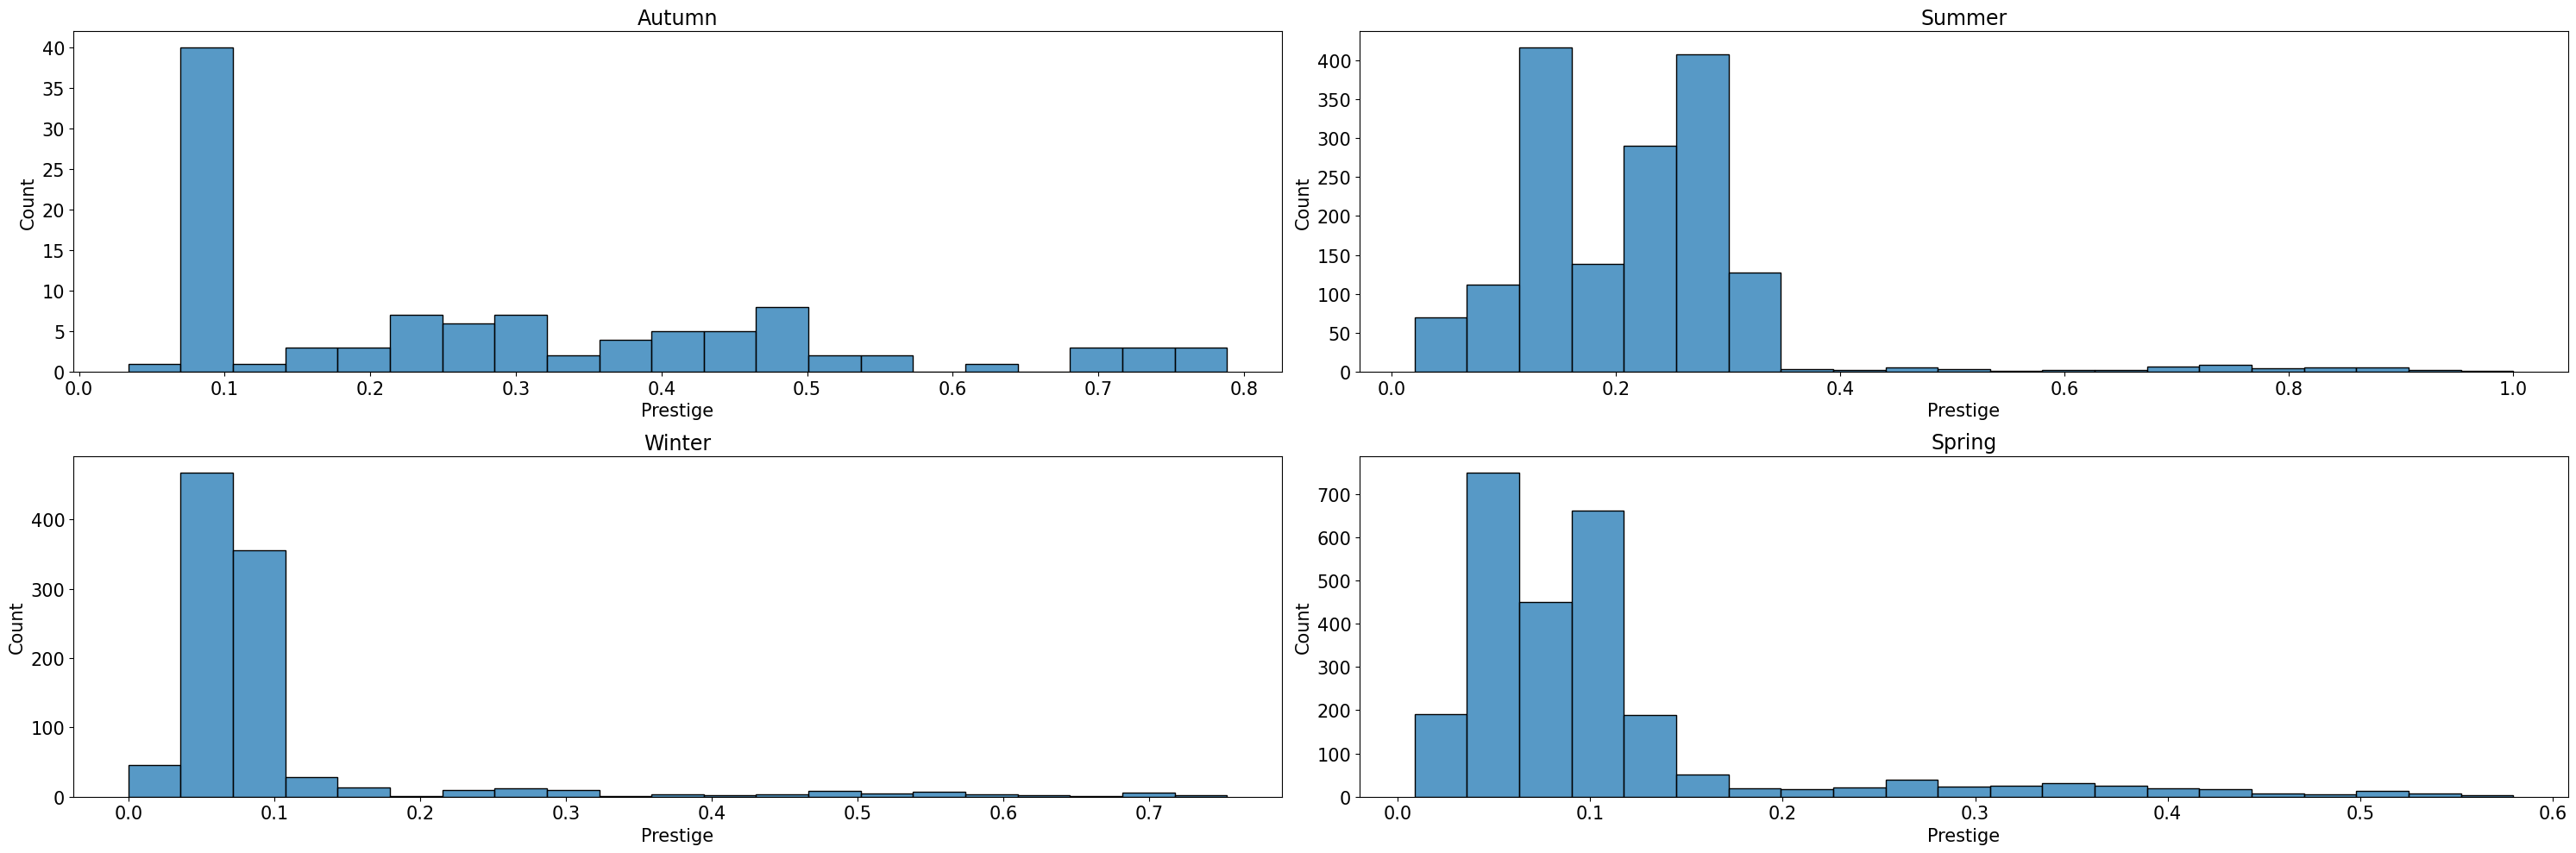

In [31]:
n_bins = math.ceil(math.log2(len(dataset)) + 1)

fig, ax = plt.subplots(2, 2, figsize=(30, 10))

sb.histplot(tmp_df[tmp_df['season'] == 'autumn'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[0, 0])
ax[0,0].set_title('Autumn', fontsize=17)
ax[0,0].set_xlabel('Prestige', fontsize=15)
ax[0,0].set_ylabel('Count', fontsize=15)
ax[0,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'summer'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[0, 1]) 
ax[0,1].set_title('Summer', fontsize=17)
ax[0,1].set_xlabel('Prestige', fontsize=15)
ax[0,1].set_ylabel('Count', fontsize=15)
ax[0,1].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'winter'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[1, 0]) 
ax[1,0].set_title('Winter', fontsize=17)
ax[1,0].set_xlabel('Prestige', fontsize=15)
ax[1,0].set_ylabel('Count', fontsize=15)
ax[1,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'spring'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="prestige", 
            bins=n_bins, 
            log_scale=False, 
            ax=ax[1, 1])
ax[1,1].set_title('Spring', fontsize=17)
ax[1,1].set_xlabel('Prestige', fontsize=15)
ax[1,1].set_ylabel('Count', fontsize=15)
ax[1,1].tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout() # Avoid overlapping

In [32]:
tmp_df.drop_duplicates(subset=['race_name', 'year', 'stage']).groupby('season')['prestige'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
autumn,106.0,0.281708,0.206159,0.033780,0.092961,0.237752,0.431860,0.788245
spring,2570.0,0.105642,0.091137,0.008811,0.053523,0.076955,0.112808,0.579532
summer,1620.0,0.218976,0.121680,0.020535,0.133807,0.230289,0.272064,1.000000
winter,985.0,0.096339,0.106456,0.000000,0.055428,0.069112,0.086879,0.753393


In [33]:
tmp_df.drop_duplicates(subset=['race_name', 'year', 'stage']).groupby('season')['bmi'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
autumn,91.0,20.611134,1.023944,19.379197,19.470778,21.037253,21.248644,23.808797
spring,1696.0,21.094066,1.079516,18.827160,20.515086,21.135785,21.705129,24.784258
summer,1237.0,20.970311,1.039611,18.827160,20.286508,21.037253,21.366869,24.304618
winter,767.0,21.136102,1.245902,18.812147,20.015496,21.200991,22.204082,25.473465


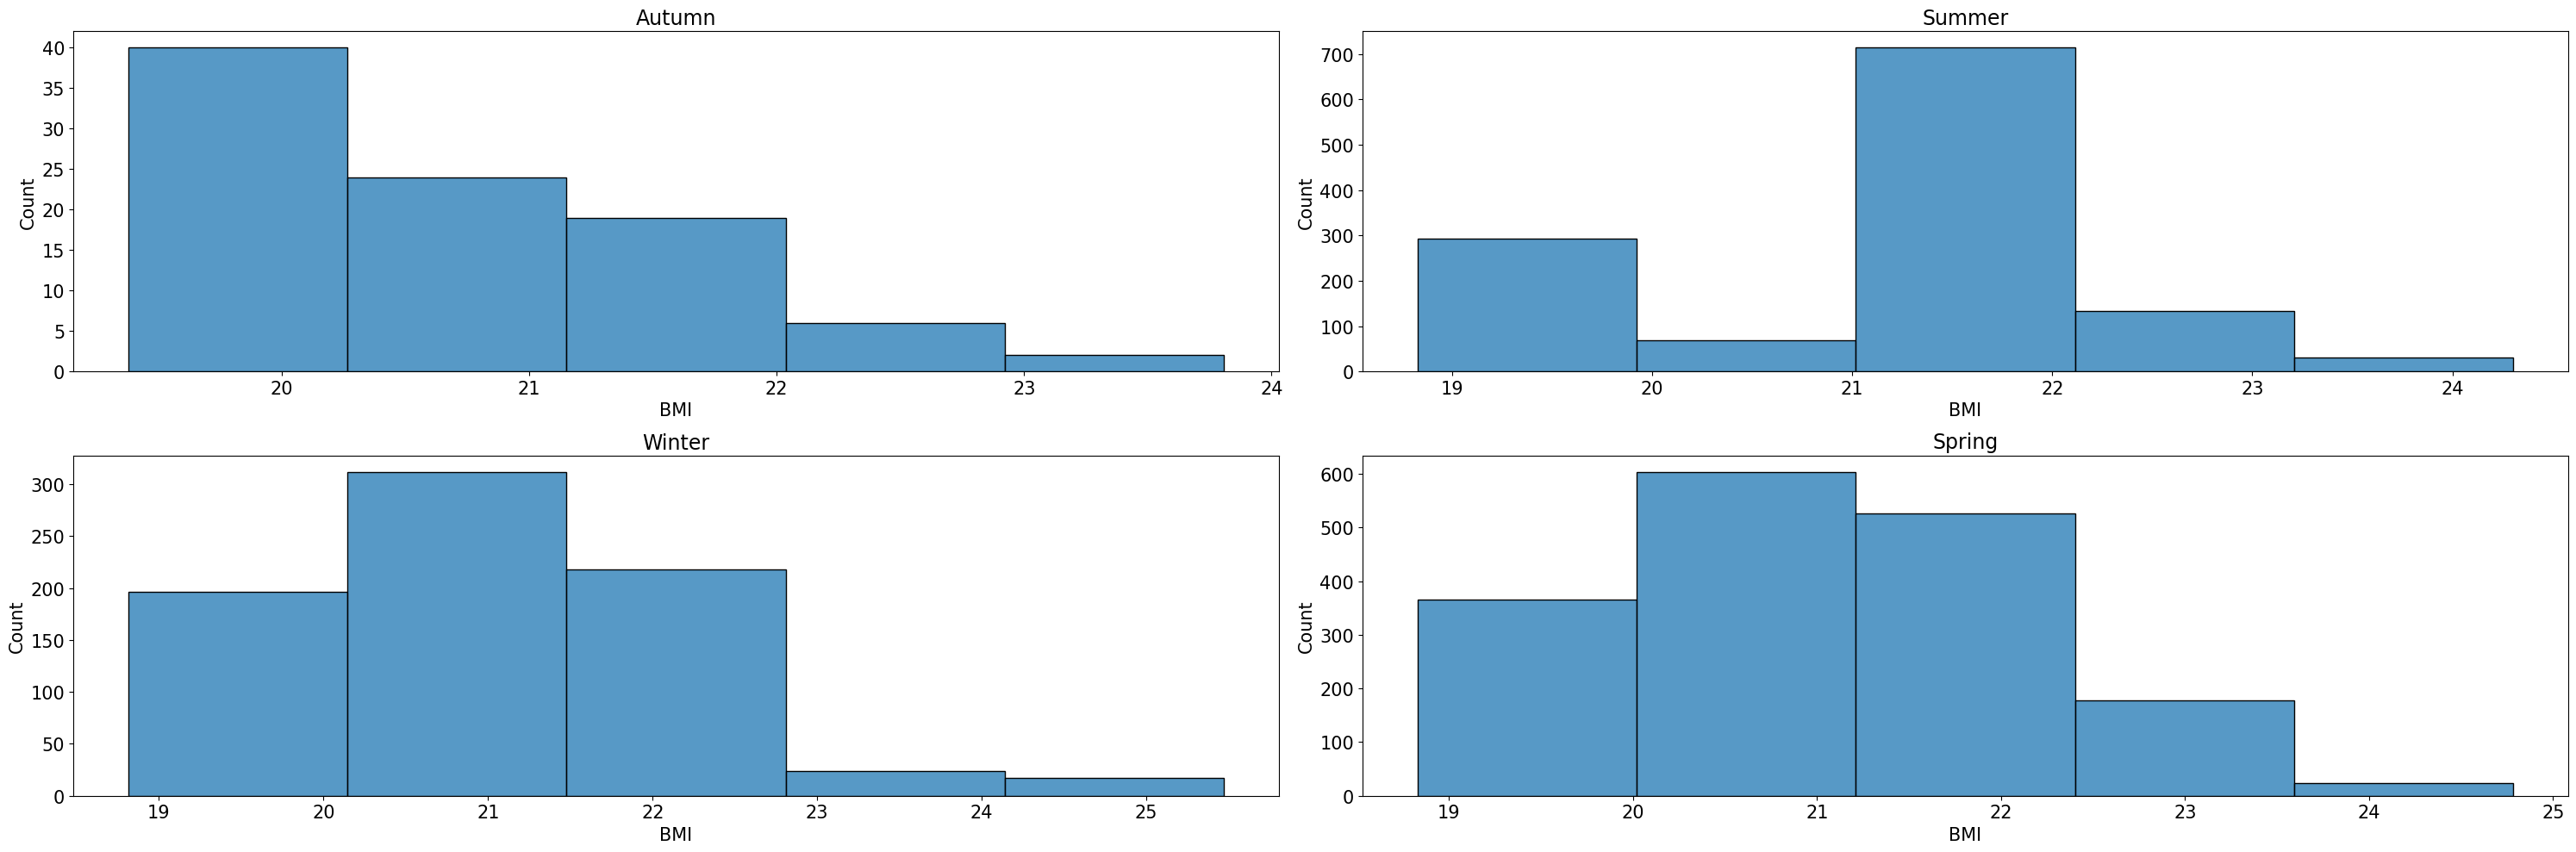

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(30, 10))

sb.histplot(tmp_df[tmp_df['season'] == 'autumn'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[0, 0])
ax[0,0].set_title('Autumn', fontsize=17)
ax[0,0].set_xlabel('BMI', fontsize=15)
ax[0,0].set_ylabel('Count', fontsize=15)
ax[0,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'summer'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[0, 1]) 
ax[0,1].set_title('Summer', fontsize=17)
ax[0,1].set_xlabel('BMI', fontsize=15)
ax[0,1].set_ylabel('Count', fontsize=15)
ax[0,1].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'winter'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[1, 0]) 
ax[1,0].set_title('Winter', fontsize=17)
ax[1,0].set_xlabel('BMI', fontsize=15)
ax[1,0].set_ylabel('Count', fontsize=15)
ax[1,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'spring'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[1, 1])
ax[1,1].set_title('Spring', fontsize=17)
ax[1,1].set_xlabel('BMI', fontsize=15)
ax[1,1].set_ylabel('Count', fontsize=15)
ax[1,1].tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout() # Avoid overlapping

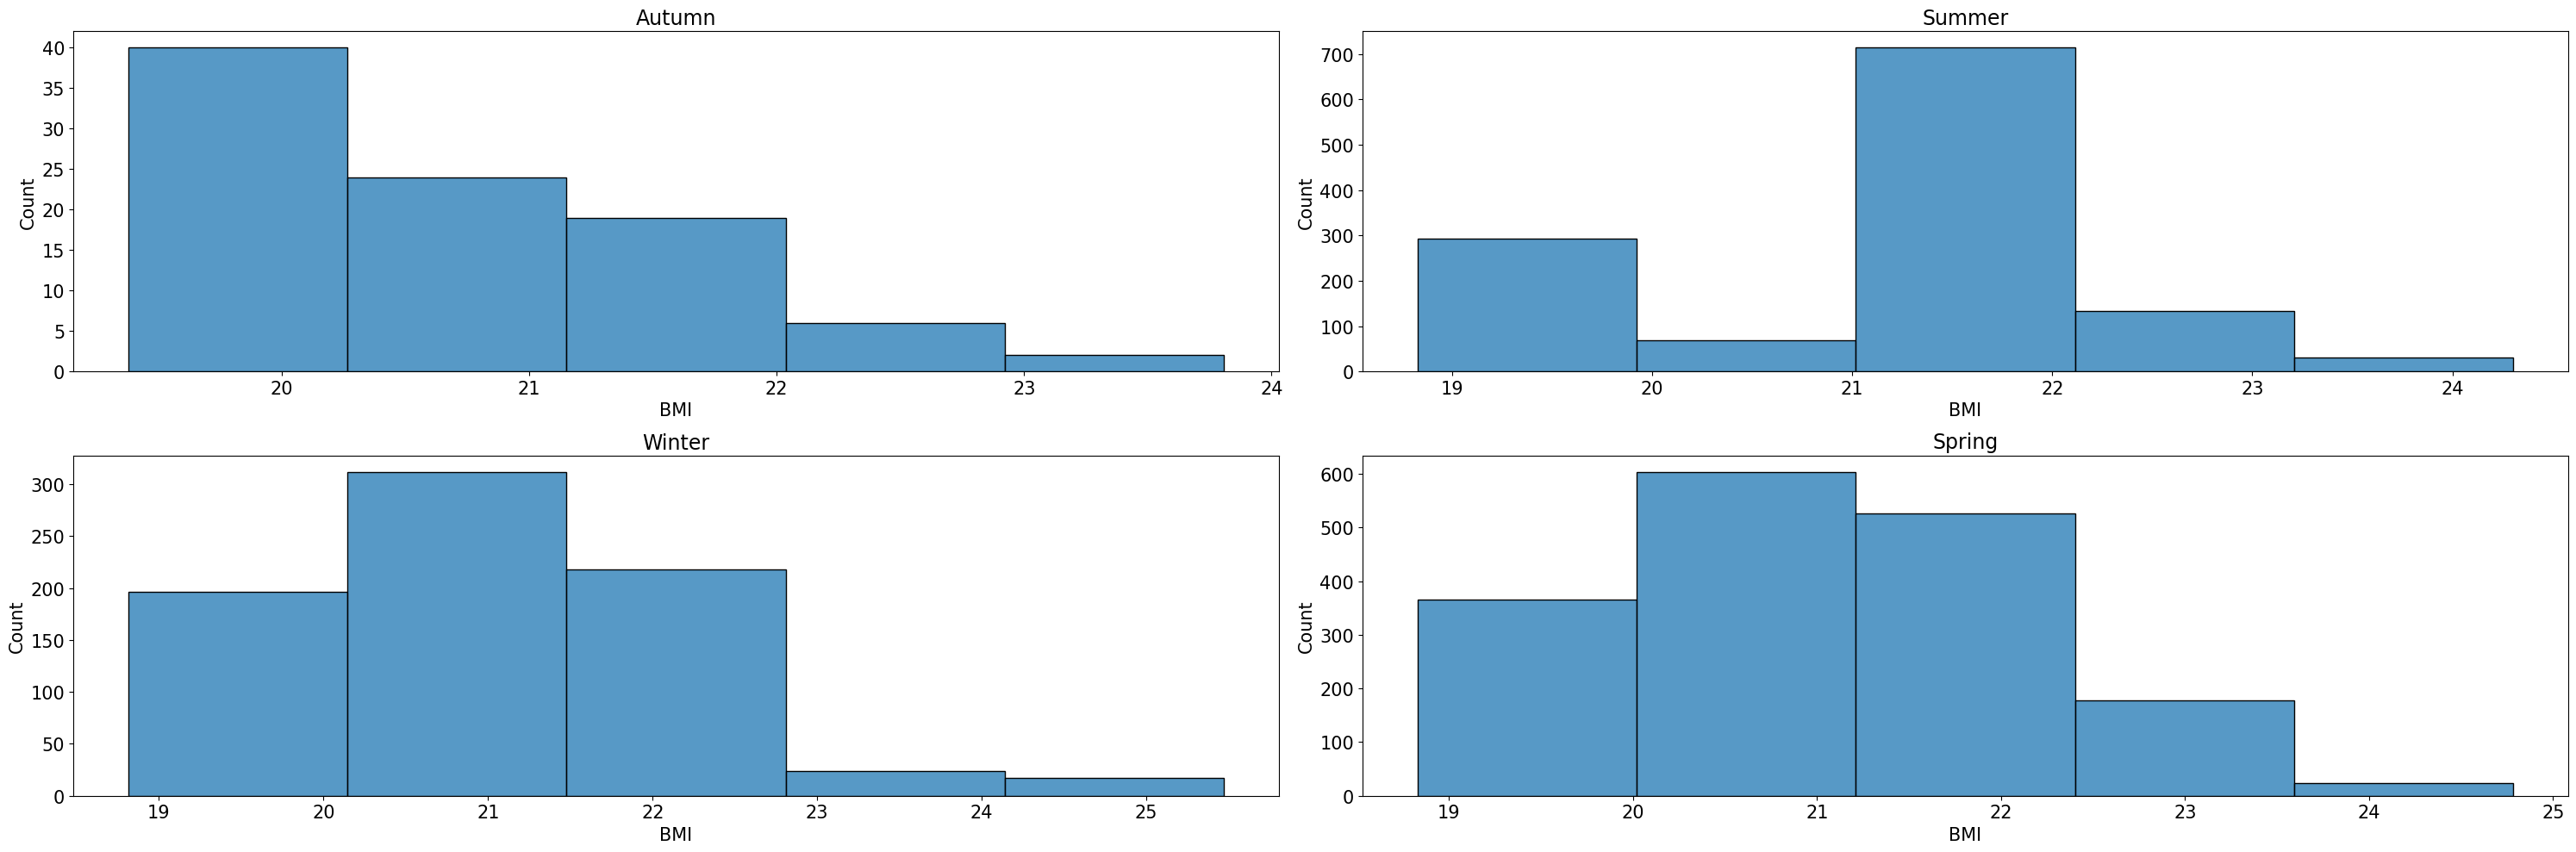

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(30, 10))

sb.histplot(tmp_df[tmp_df['season'] == 'autumn'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[0, 0])
ax[0,0].set_title('Autumn', fontsize=17)
ax[0,0].set_xlabel('BMI', fontsize=15)
ax[0,0].set_ylabel('Count', fontsize=15)
ax[0,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'summer'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[0, 1]) 
ax[0,1].set_title('Summer', fontsize=17)
ax[0,1].set_xlabel('BMI', fontsize=15)
ax[0,1].set_ylabel('Count', fontsize=15)
ax[0,1].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'winter'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[1, 0]) 
ax[1,0].set_title('Winter', fontsize=17)
ax[1,0].set_xlabel('BMI', fontsize=15)
ax[1,0].set_ylabel('Count', fontsize=15)
ax[1,0].tick_params(axis='both', which='major', labelsize=15)

sb.histplot(tmp_df[tmp_df['season'] == 'spring'].drop_duplicates(subset=['race_name', 'stage', 'year']), 
            x="bmi", 
            bins=5, 
            log_scale=False, 
            ax=ax[1, 1])
ax[1,1].set_title('Spring', fontsize=17)
ax[1,1].set_xlabel('BMI', fontsize=15)
ax[1,1].set_ylabel('Count', fontsize=15)
ax[1,1].tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout() # Avoid overlapping

In [36]:
team_season = pd.crosstab(tmp_df['team'], tmp_df['season'], normalize='index').reset_index()

team_season['autumn'] = (team_season['autumn'] / team_season['autumn'].max())
team_season['spring'] = (team_season['spring'] / team_season['spring'].max())
team_season['summer'] = (team_season['summer'] / team_season['summer'].max())
team_season['winter'] = (team_season['winter'] / team_season['winter'].max())

print("Most present Team for Season\n")
print(team_season[team_season['autumn'] == team_season['autumn'].max()],"\n",
team_season[team_season['spring'] == team_season['spring'].max()],"\n",
team_season[team_season['summer'] == team_season['summer'].max()],"\n",
team_season[team_season['winter'] == team_season['winter'].max()])

print("\n\nLess present Team for Season\n")
print(team_season[team_season['autumn'] == team_season['autumn'].min()],"\n",
team_season[team_season['spring'] == team_season['spring'].min()],"\n",
team_season[team_season['summer'] == team_season['summer'].min()],"\n",
team_season[team_season['winter'] == team_season['winter'].min()])


Most present Team for Season

season               team  autumn    spring    summer    winter
71      south-africa-2022     1.0  0.558148  0.700441  0.156627 
 season          team  autumn  spring    summer   winter
26      denmark-2003     0.0     1.0  0.009704  0.25463 
 season                  team    autumn    spring  summer    winter
62      o.n.c.e.-eroski-2003  0.066343  0.495587     1.0  0.149448 
 season                       team  autumn  spring  summer  winter
63      quickstep-innergetic-2009     0.0     0.0     0.0     1.0


Less present Team for Season

season                       team  autumn  spring    summer   winter
26                   denmark-2003     0.0     1.0  0.009704  0.25463
63      quickstep-innergetic-2009     0.0     0.0  0.000000  1.00000 
 season                       team  autumn  spring  summer  winter
63      quickstep-innergetic-2009     0.0     0.0     0.0     1.0 
 season                       team  autumn  spring  summer  winter
63      quickstep

In [37]:
tmp_df = pd.DataFrame({
    'race_name': dataset['race_name'],
    'stage': dataset['race_stage'],
    'team': dataset['cyclist_team'],
    'bmi': dataset['cyclist_bmi'],
    'year': dataset['date'].dt.year,
})

### Physical Effort Attribute

In [38]:
mean_efforts = dataset.groupby(by=['race_name', 'race_year'])['race_physical_effort'].mean().reset_index()

In [39]:
race_prestige = dataset.groupby(by=['race_name', 'race_year'])['race_prestige'].mean().reset_index()

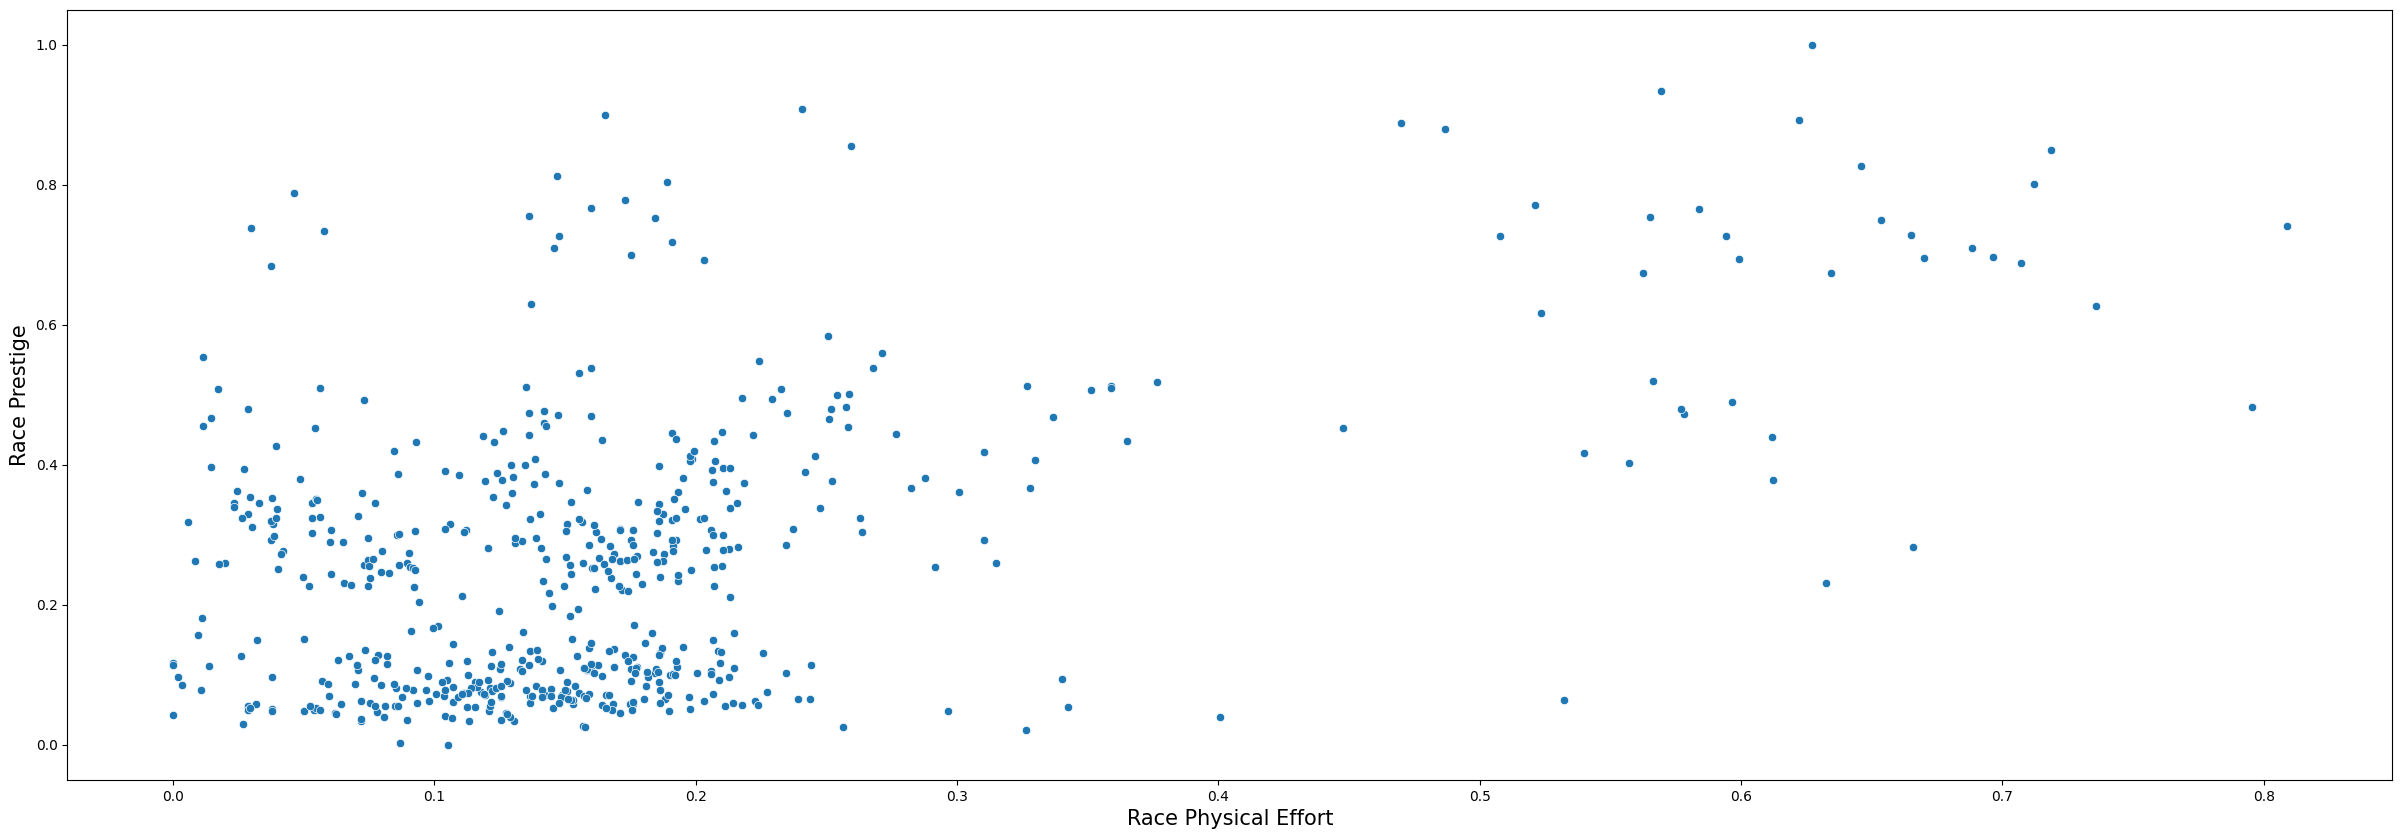

In [40]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x=mean_efforts['race_physical_effort'],
    y=race_prestige['race_prestige'])
plt.xlabel('Race Physical Effort', fontsize=15)
plt.ylabel('Race Prestige', fontsize=15)
plt.show()

Prestige tends to improve with increasing physical effort of the race.

In [41]:
race_points = dataset.groupby(by=['race_name', 'race_year'])['points'].mean().reset_index()

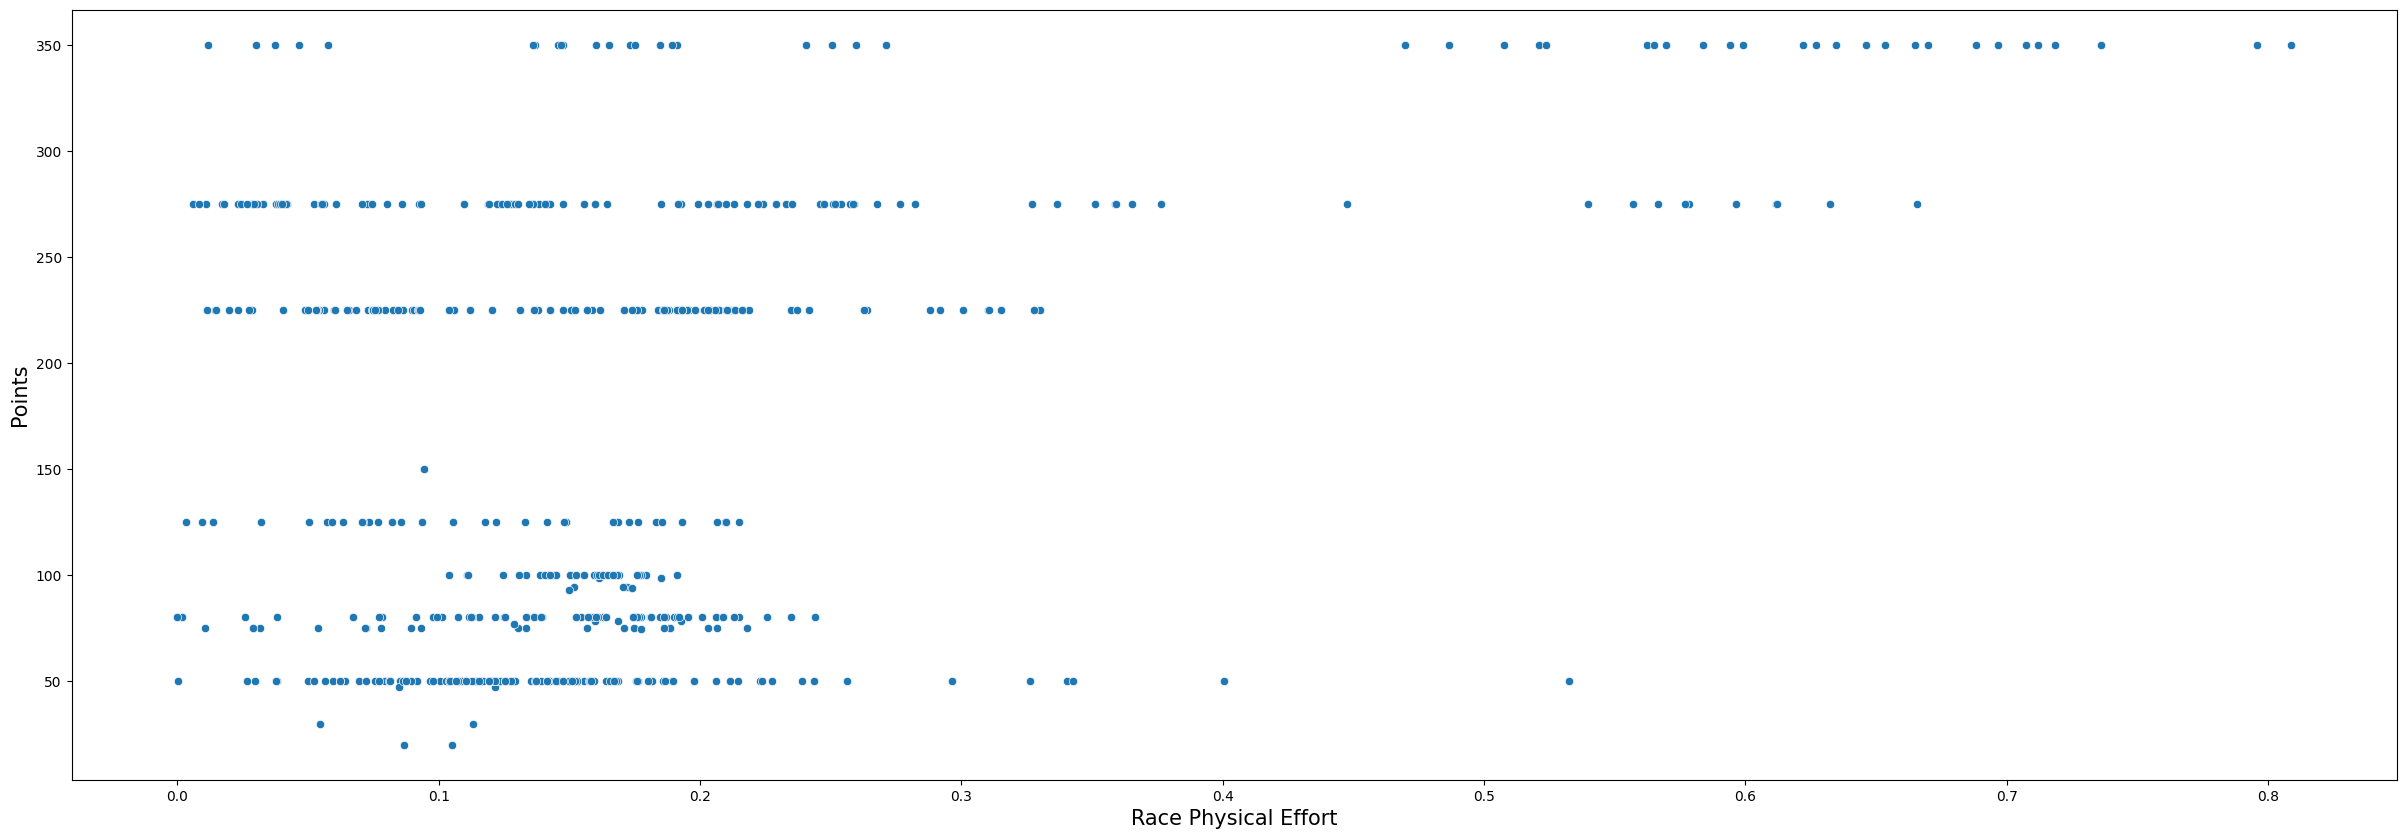

In [42]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x=mean_efforts['race_physical_effort'],
    y=race_points['points'])
plt.xlabel('Race Physical Effort', fontsize=15)
plt.ylabel('Points', fontsize=15)
plt.show()

The points tend to increase with the physical effort, but the cluster of points between 50 and 150 corresponding to the physical effort of 0.1 and 0.2 tends to concentrate most of the races there compared to their prestige.

In [43]:
race_startlists = dataset.groupby(by=['race_name', 'race_year'])['startlist_quality'].unique().reset_index()
race_startlists['startlist_quality'] = race_startlists['startlist_quality'].apply(lambda x: x[0])

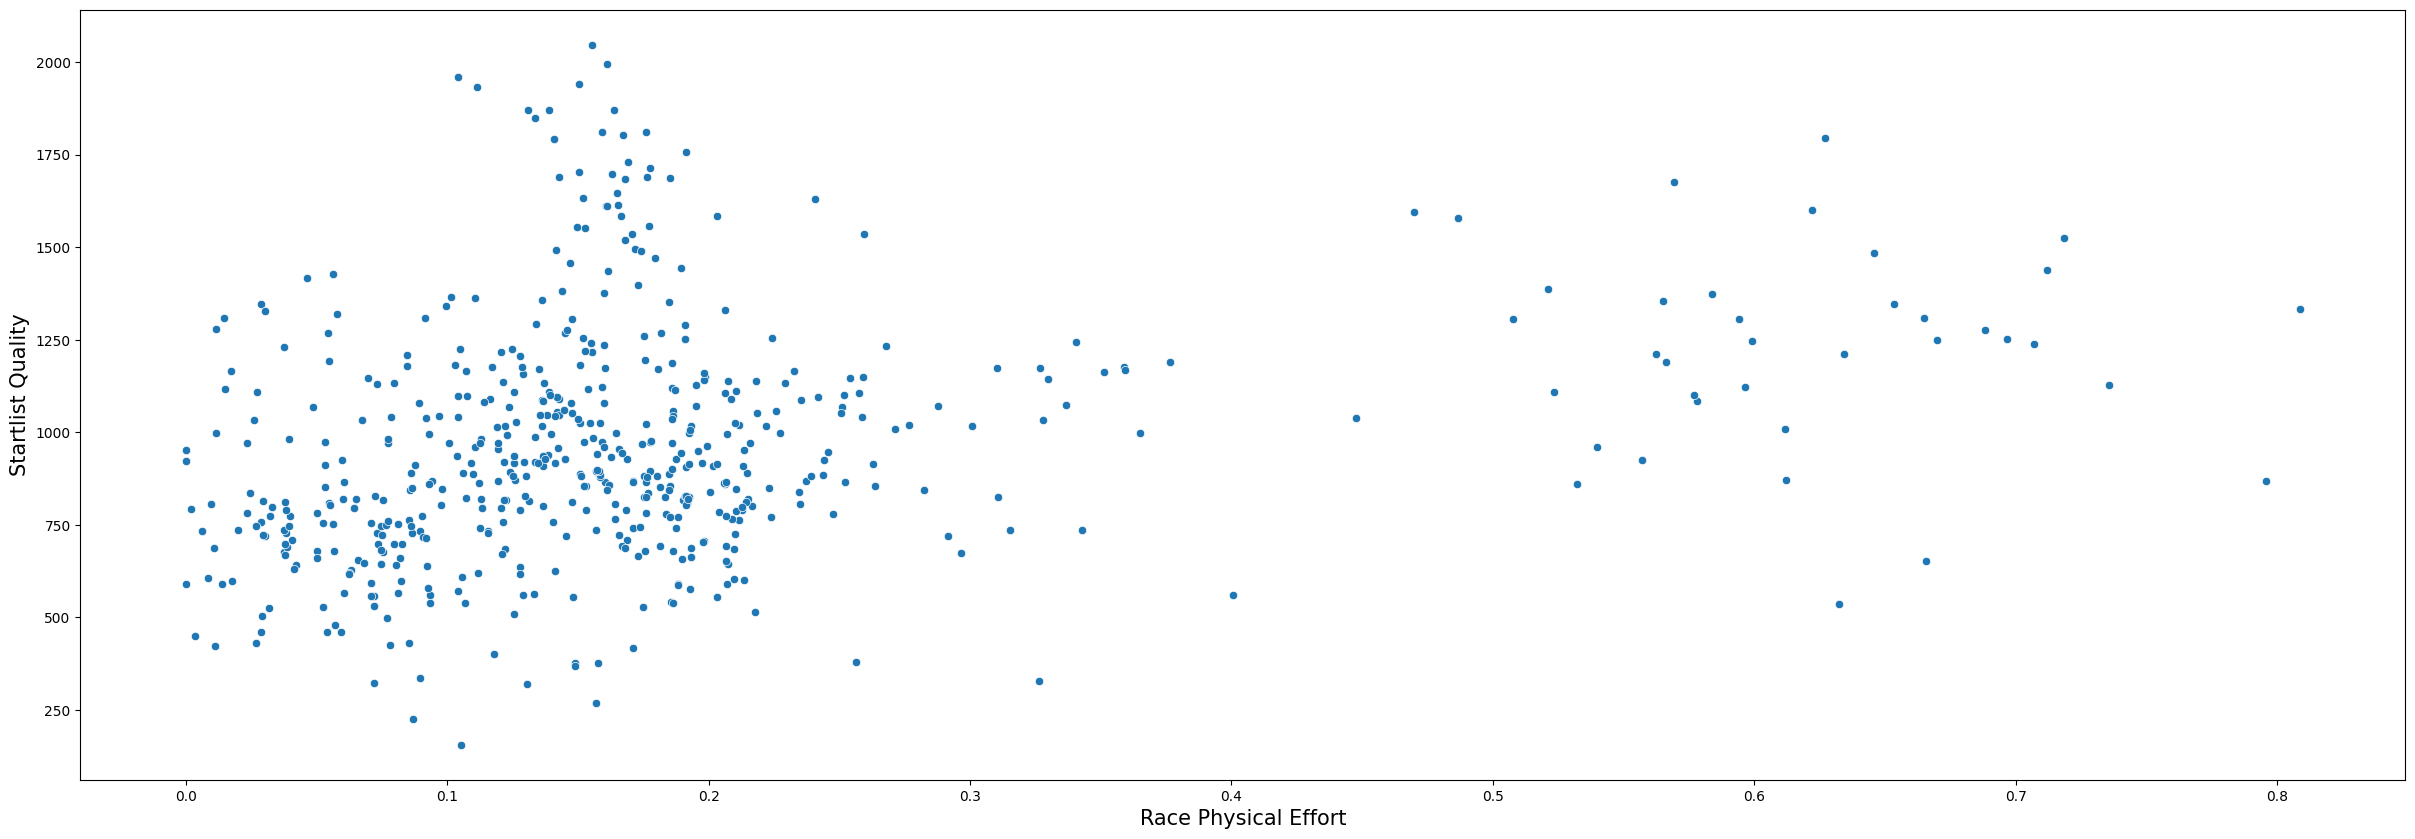

In [44]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x=mean_efforts['race_physical_effort'],
    y=race_startlists['startlist_quality'])
plt.xlabel('Race Physical Effort', fontsize=15)
plt.ylabel('Startlist Quality', fontsize=15)
plt.show()

There doesn't seem to be a strong correlation between physical effort and startlist quality, as the most prestigious races have an effort between 0.1 and 0.3.

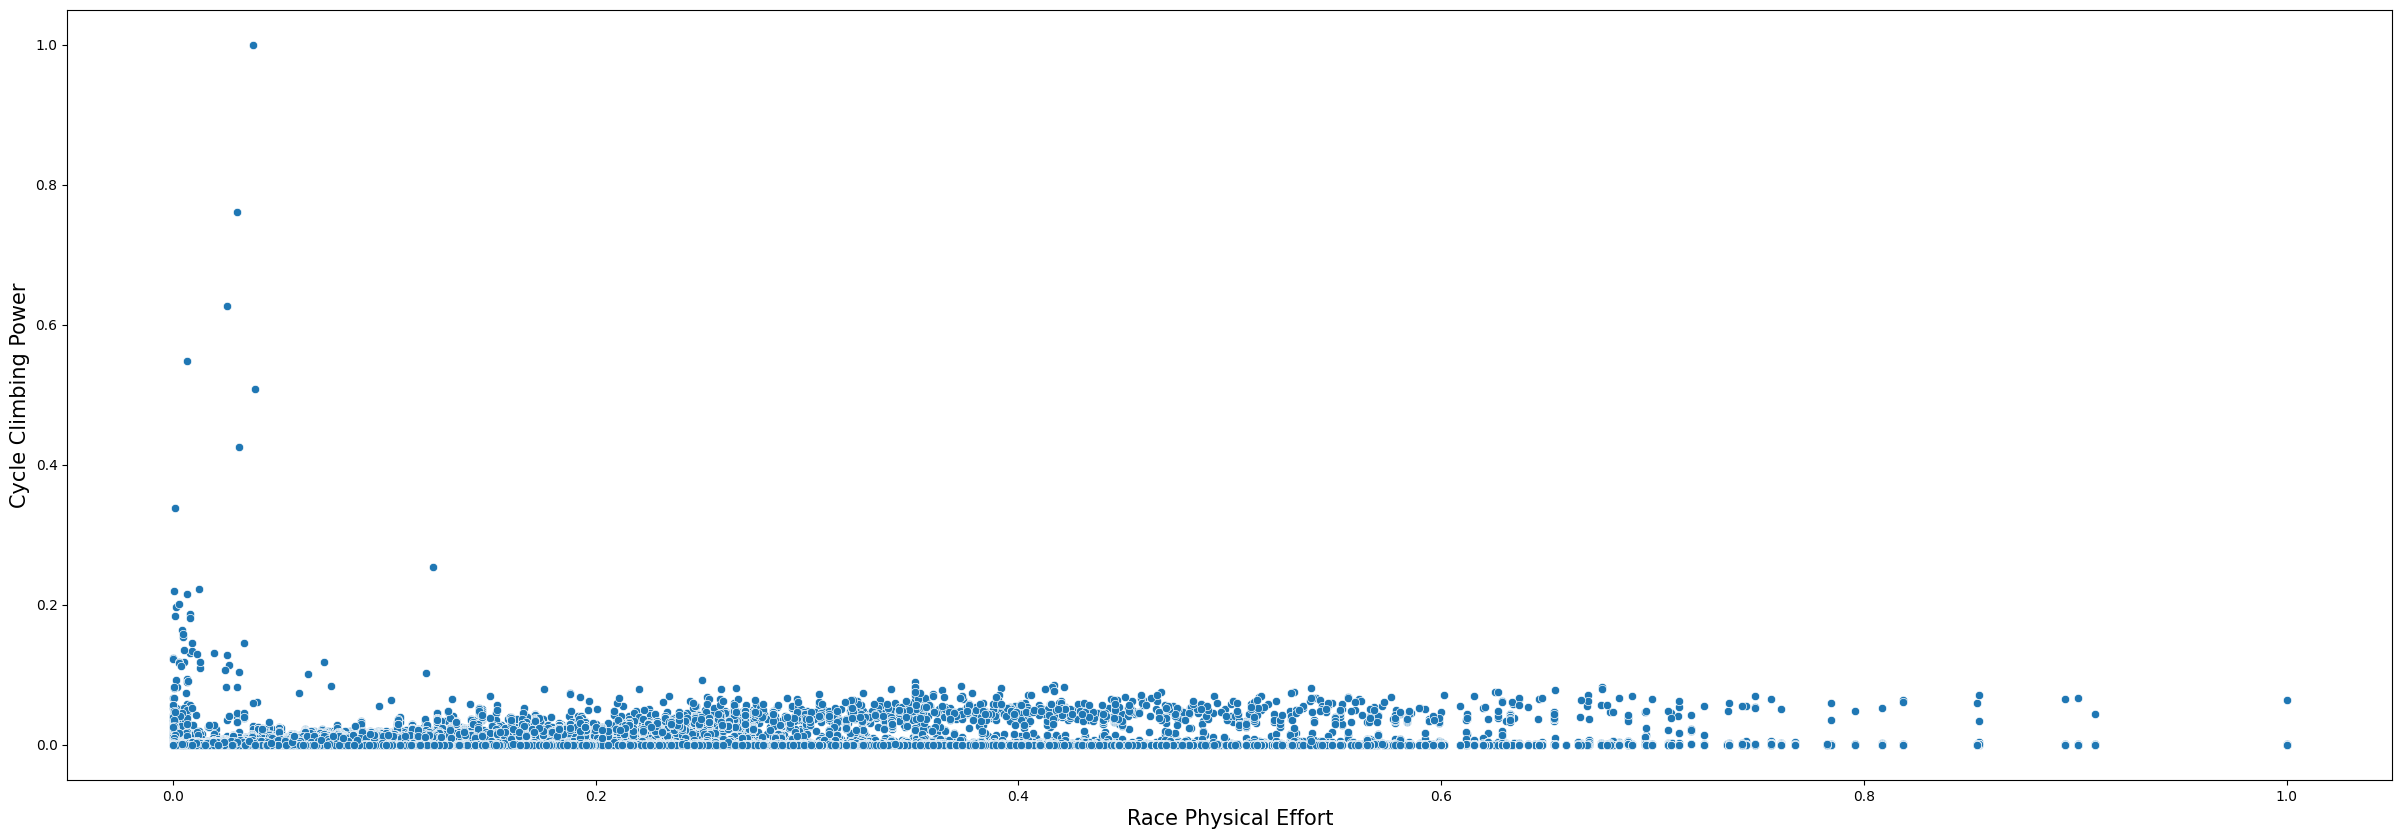

In [45]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='race_physical_effort',
    y='cyclist_climb_power',
    data=dataset)
plt.xlabel('Race Physical Effort', fontsize=15)
plt.ylabel('Cycle Climbing Power', fontsize=15)
plt.show()

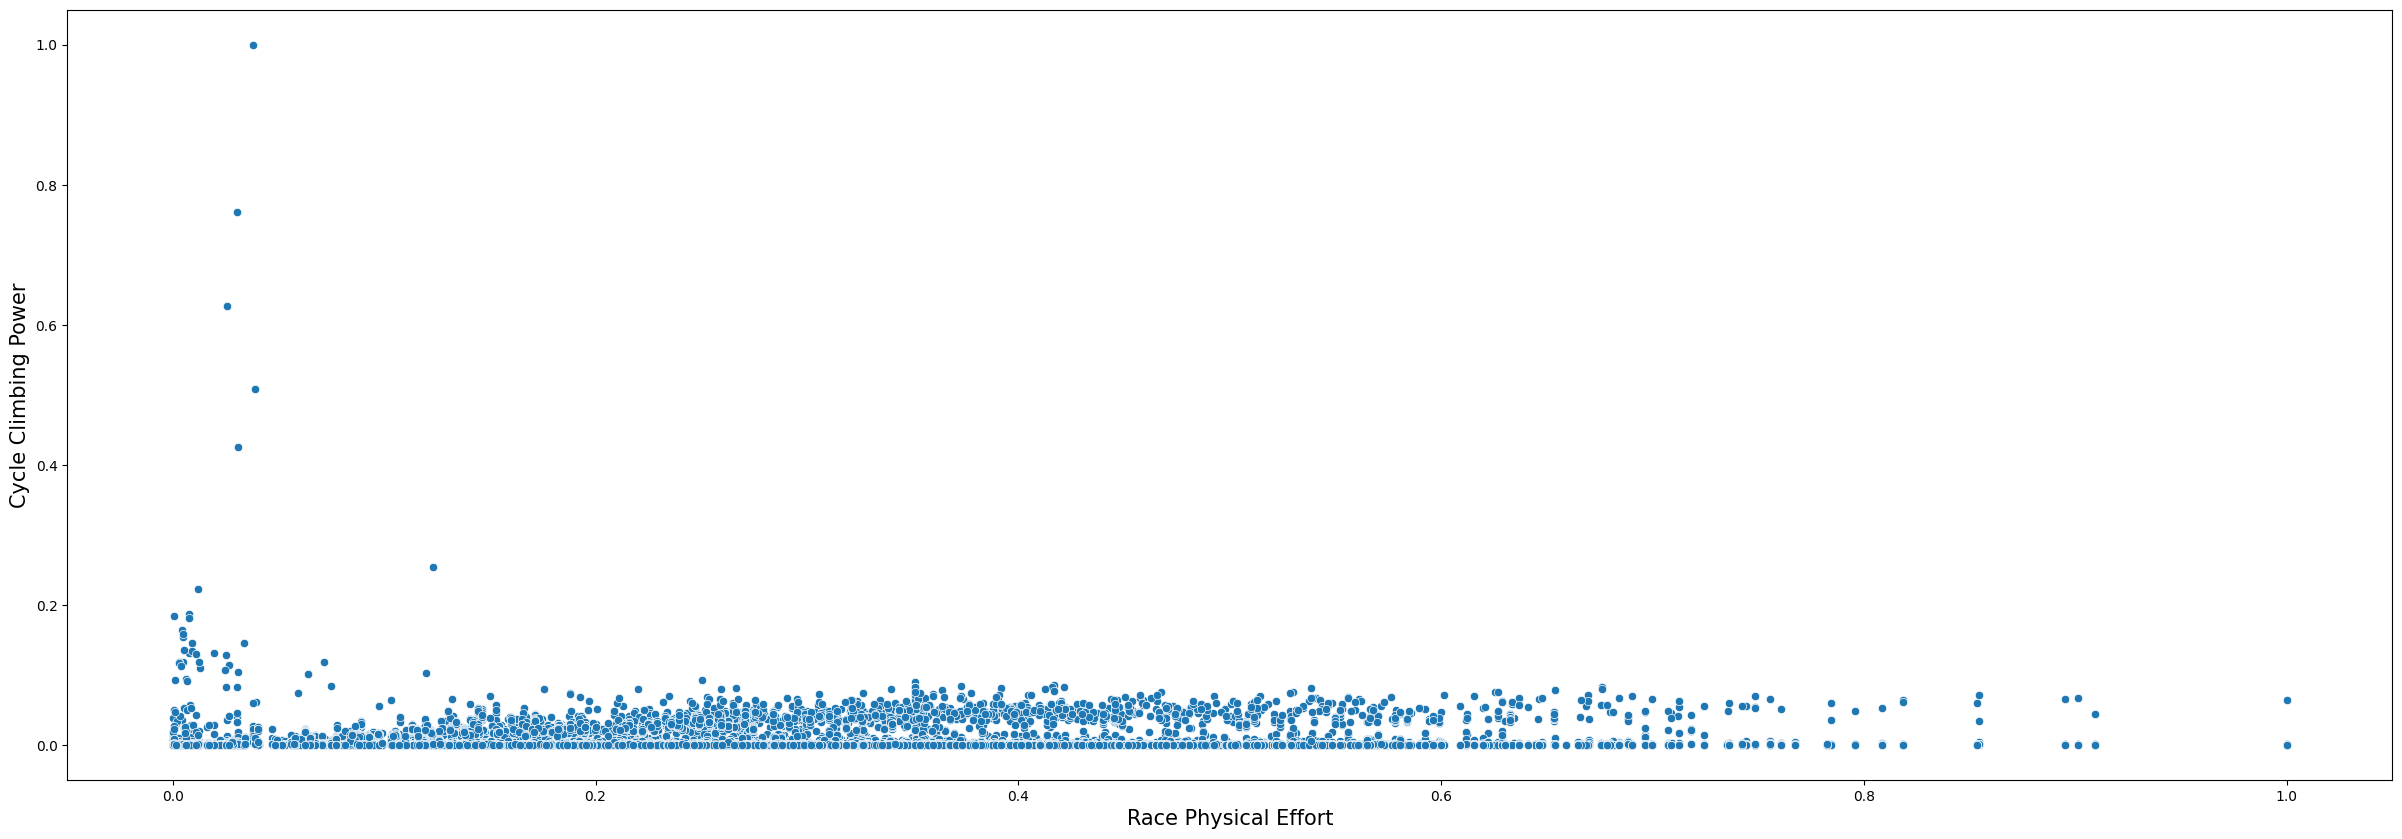

In [46]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='race_physical_effort',
    y='cyclist_climb_power',
    data=dataset[dataset['profile'] > 2])
plt.xlabel('Race Physical Effort', fontsize=15)
plt.ylabel('Cycle Climbing Power', fontsize=15)
plt.show()

### Prestige Attribute


Text(5.069444444444445, 0.5, 'Count')

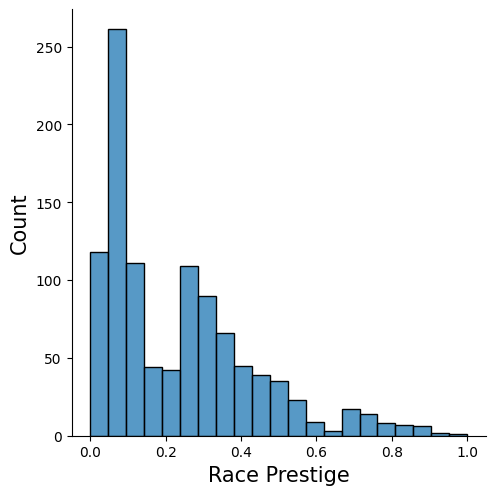

In [47]:
n_bins = math.ceil(math.log2(len(dataset)) + 1)
tmp_df = dataset.drop_duplicates(subset=['race_name', 'race_year'])

sb.displot(tmp_df, 
                x="race_prestige", 
                kind="hist",
                row_order="desc",
                bins=n_bins)
plt.xlabel('Race Prestige', fontsize=15)
plt.ylabel('Count', fontsize=15)

Most of the races in our dataset have a prestige below 0.4

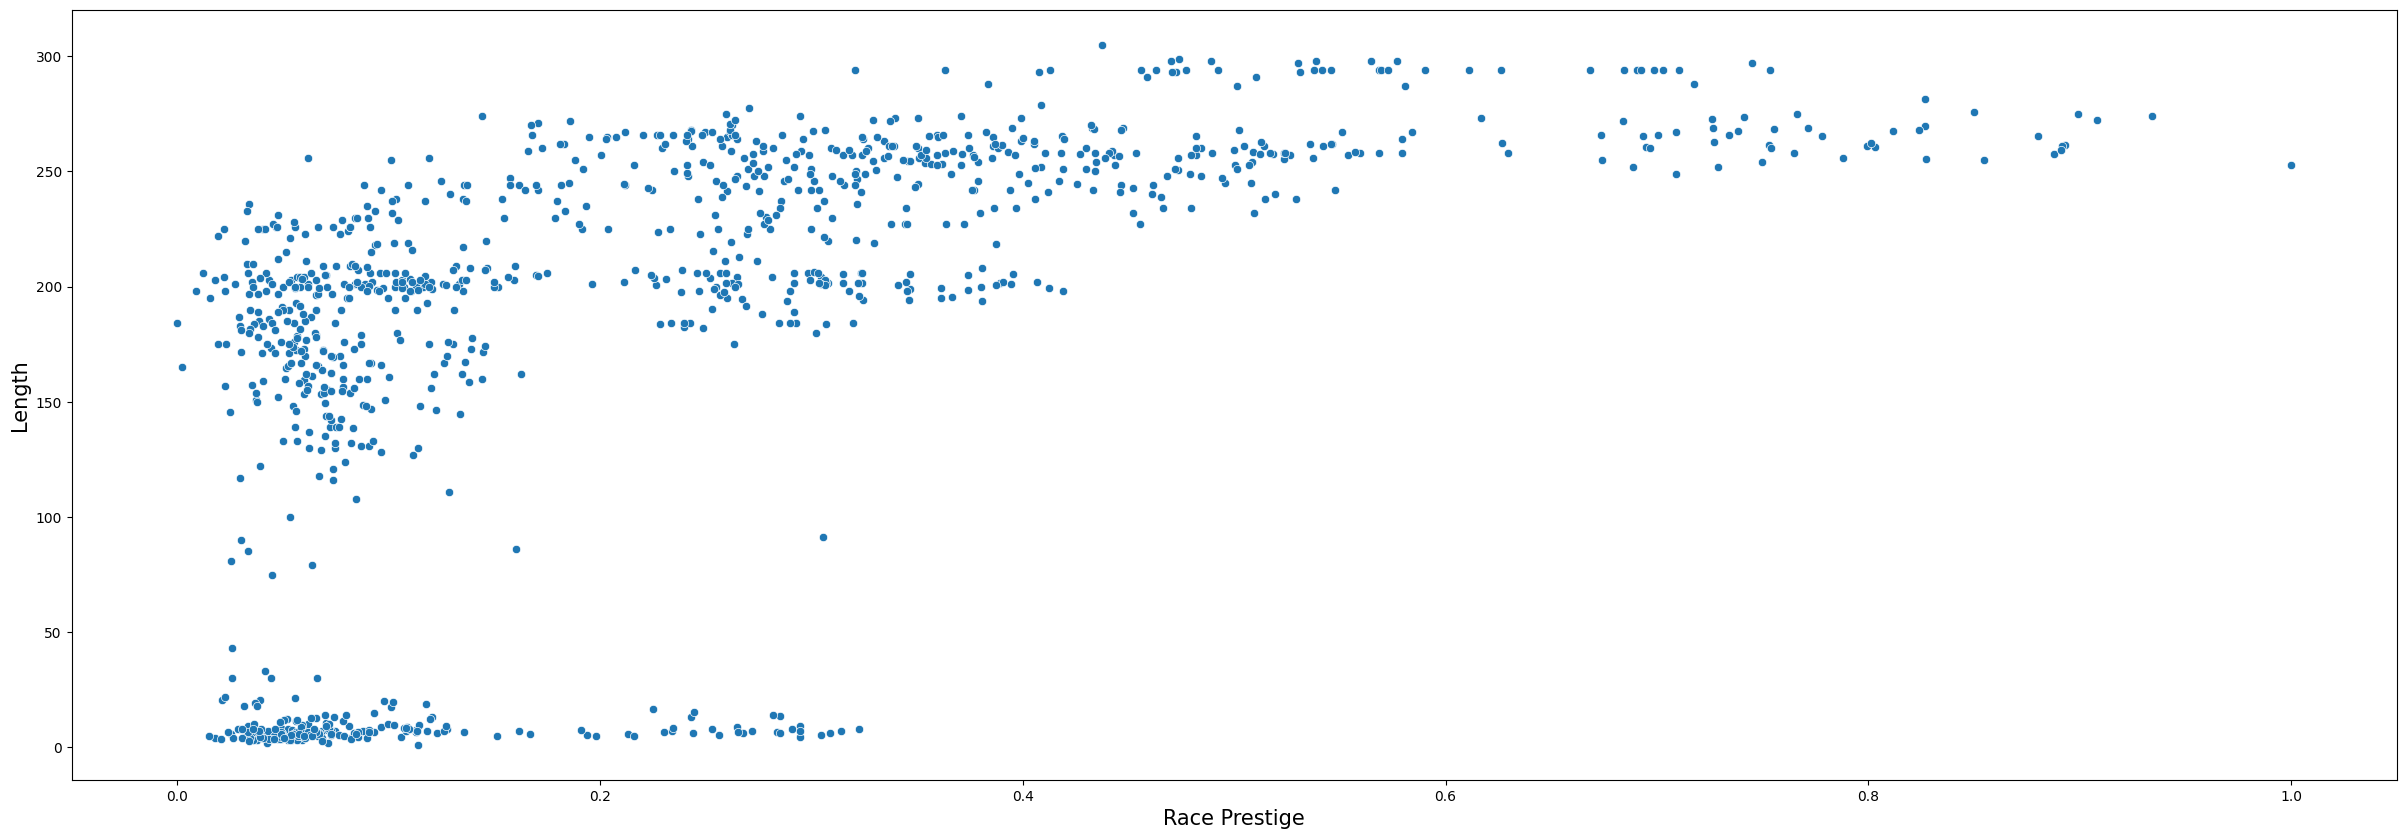

In [48]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='race_prestige',
    y='length',
    data=tmp_df)
plt.xlabel('Race Prestige', fontsize=15)
plt.ylabel('Length', fontsize=15)
plt.show()

Probably the average prestige increases with length, although high prestige races seem to be able to be very short as well

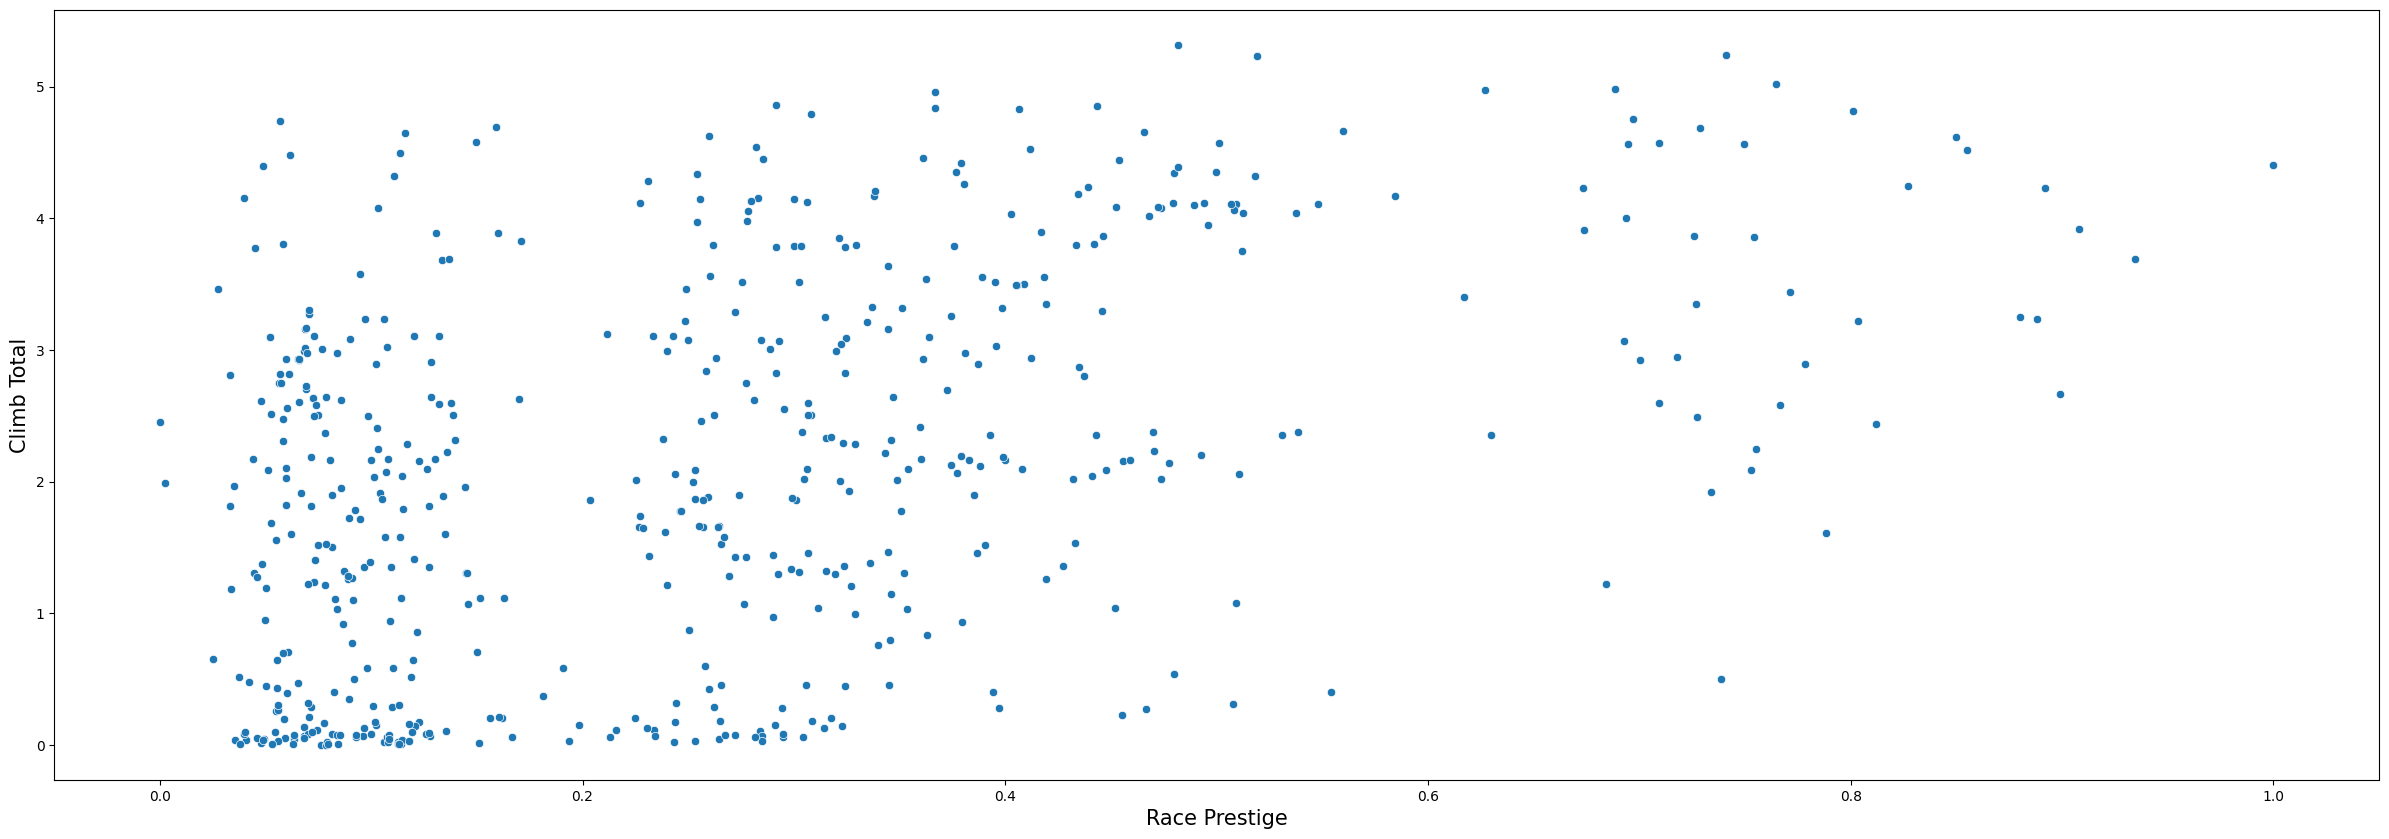

In [49]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='race_prestige',
    y='climb_total',
    data=tmp_df)
plt.xlabel('Race Prestige', fontsize=15)
plt.ylabel('Climb Total', fontsize=15)
plt.show()

We have a similar trend with climb total

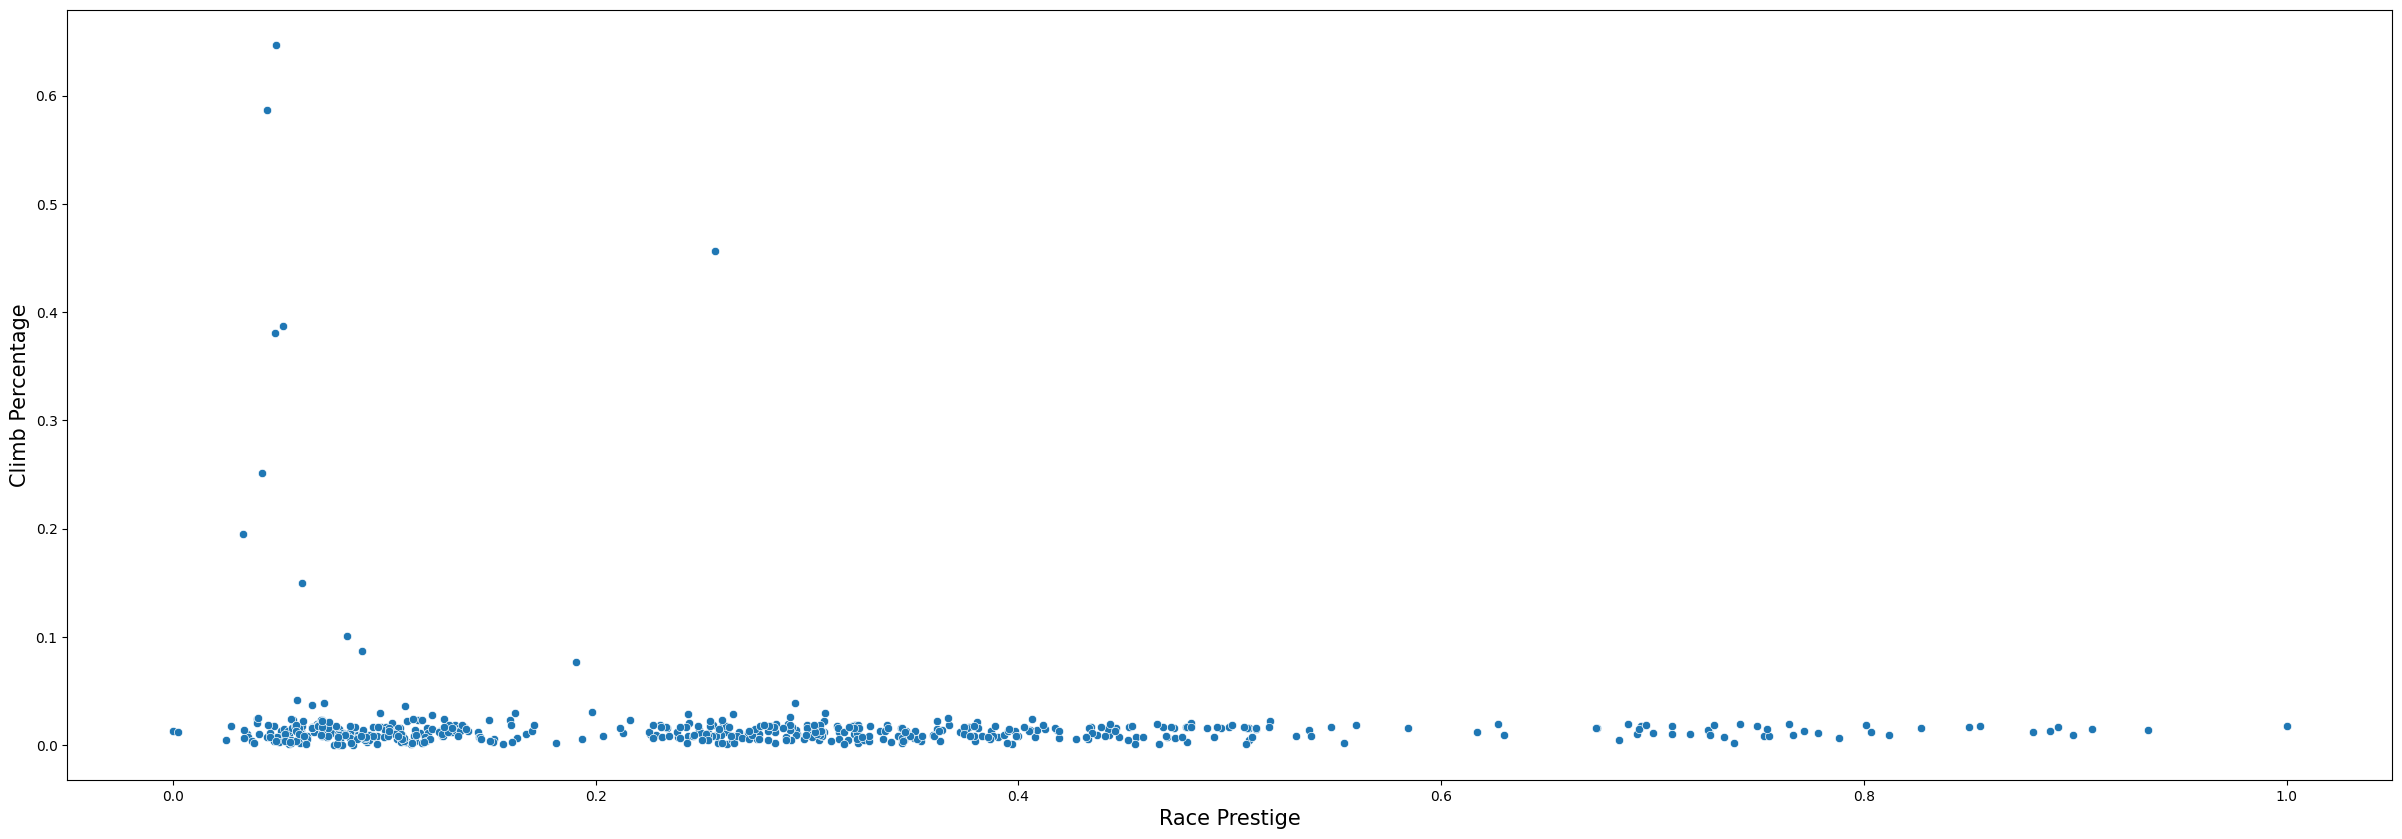

In [50]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='race_prestige',
    y='climb_percentage',
    data=tmp_df)
plt.xlabel('Race Prestige', fontsize=15)
plt.ylabel('Climb Percentage', fontsize=15)
plt.show()

However, the same does not apply to the climb percentage, implying that the total length of the race is still very influential

### Previous Experience

Text(-12.430555555555555, 0.5, 'Count')

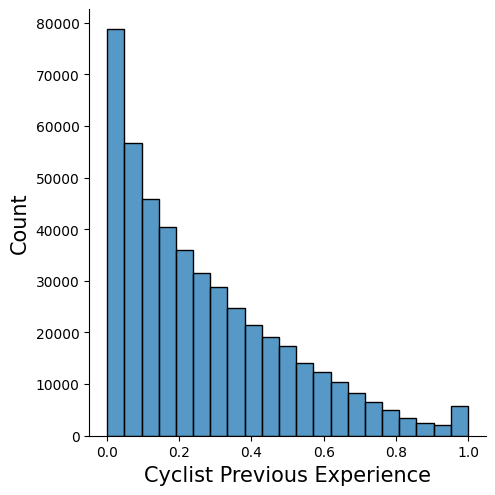

In [51]:
n_bins = math.ceil(math.log2(len(dataset)) + 1)

sb.displot(dataset, 
                x="cyclist_previous_experience", 
                kind="hist",
                row_order="desc",
                bins=n_bins)
plt.xlabel('Cyclist Previous Experience', fontsize=15)
plt.ylabel('Count', fontsize=15)

There are many cyclists with "little" experience, probably due to the fact that many cyclists appear in few stages

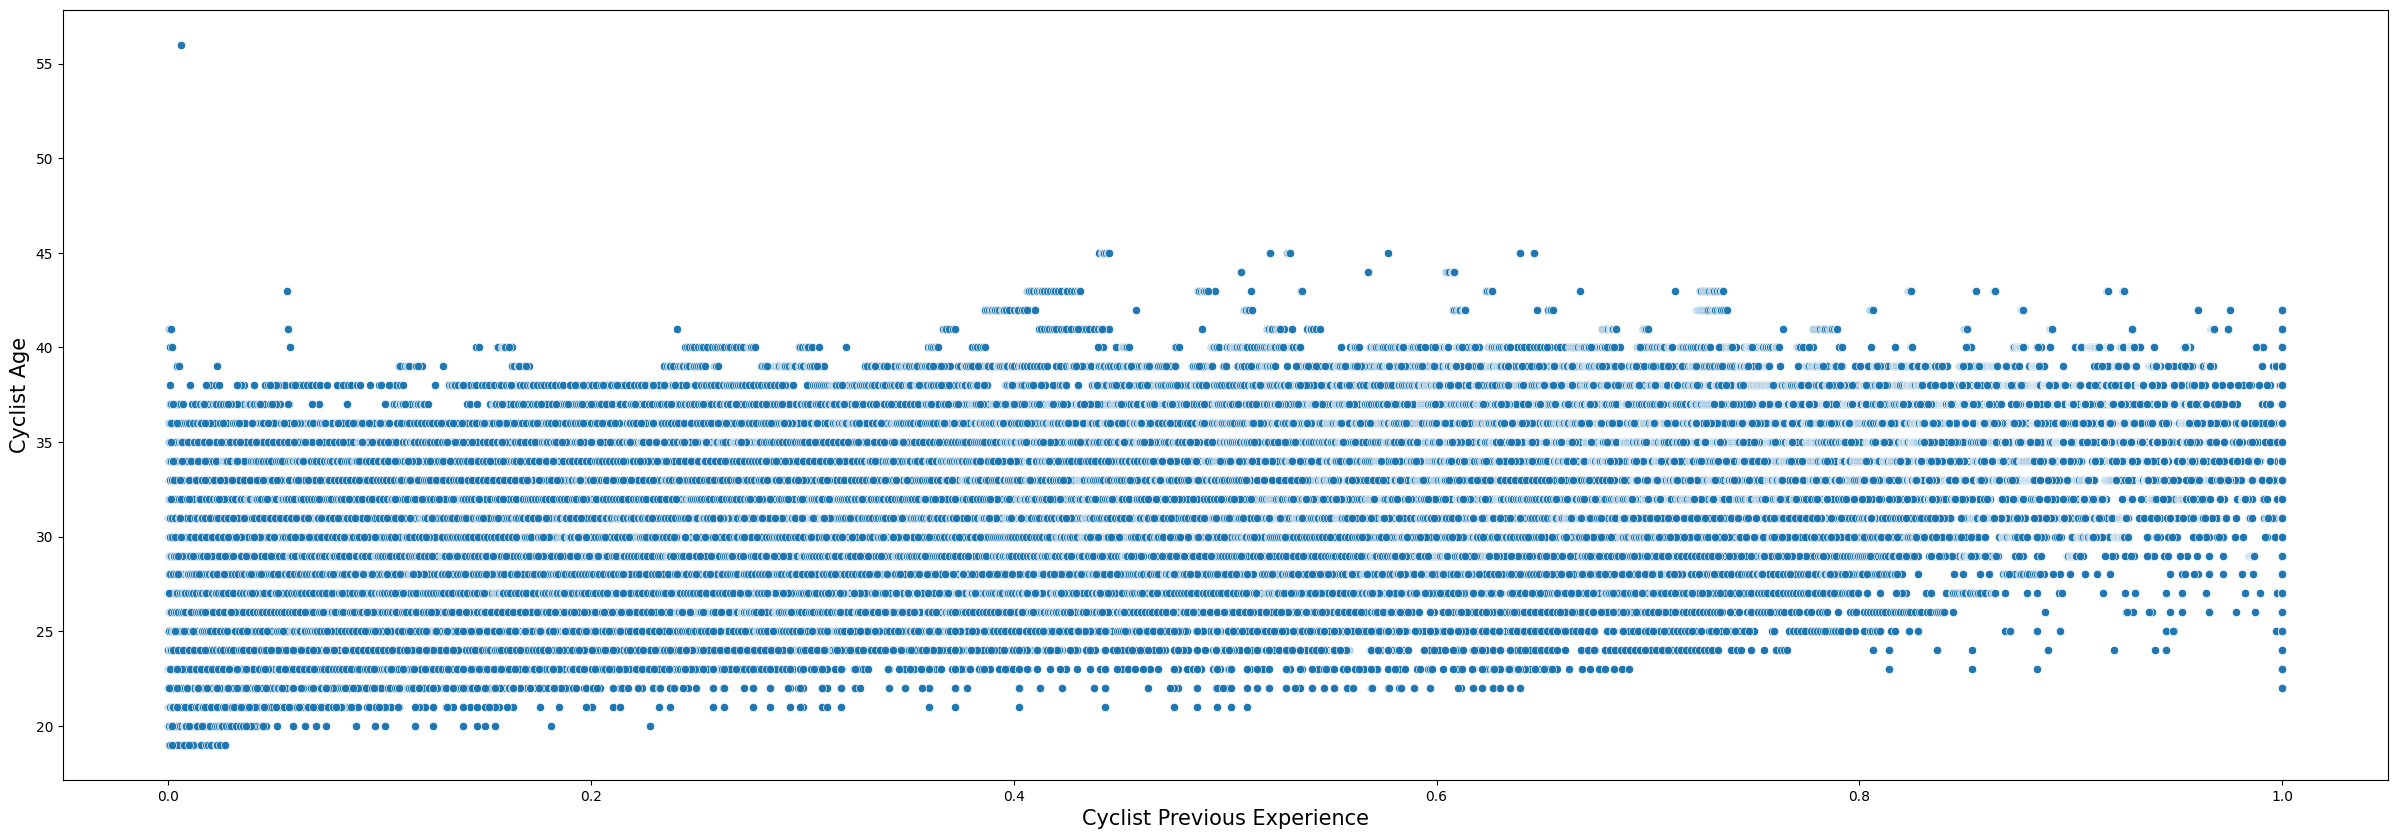

In [52]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_previous_experience',
    y='cyclist_age',
    data=dataset)
plt.xlabel('Cyclist Previous Experience', fontsize=15)
plt.ylabel('Cyclist Age', fontsize=15)
plt.show()

From the graph, we can see a slight correlation between the cyclist's age and their experience. In fact, there are few young cyclists with a lot of experience.

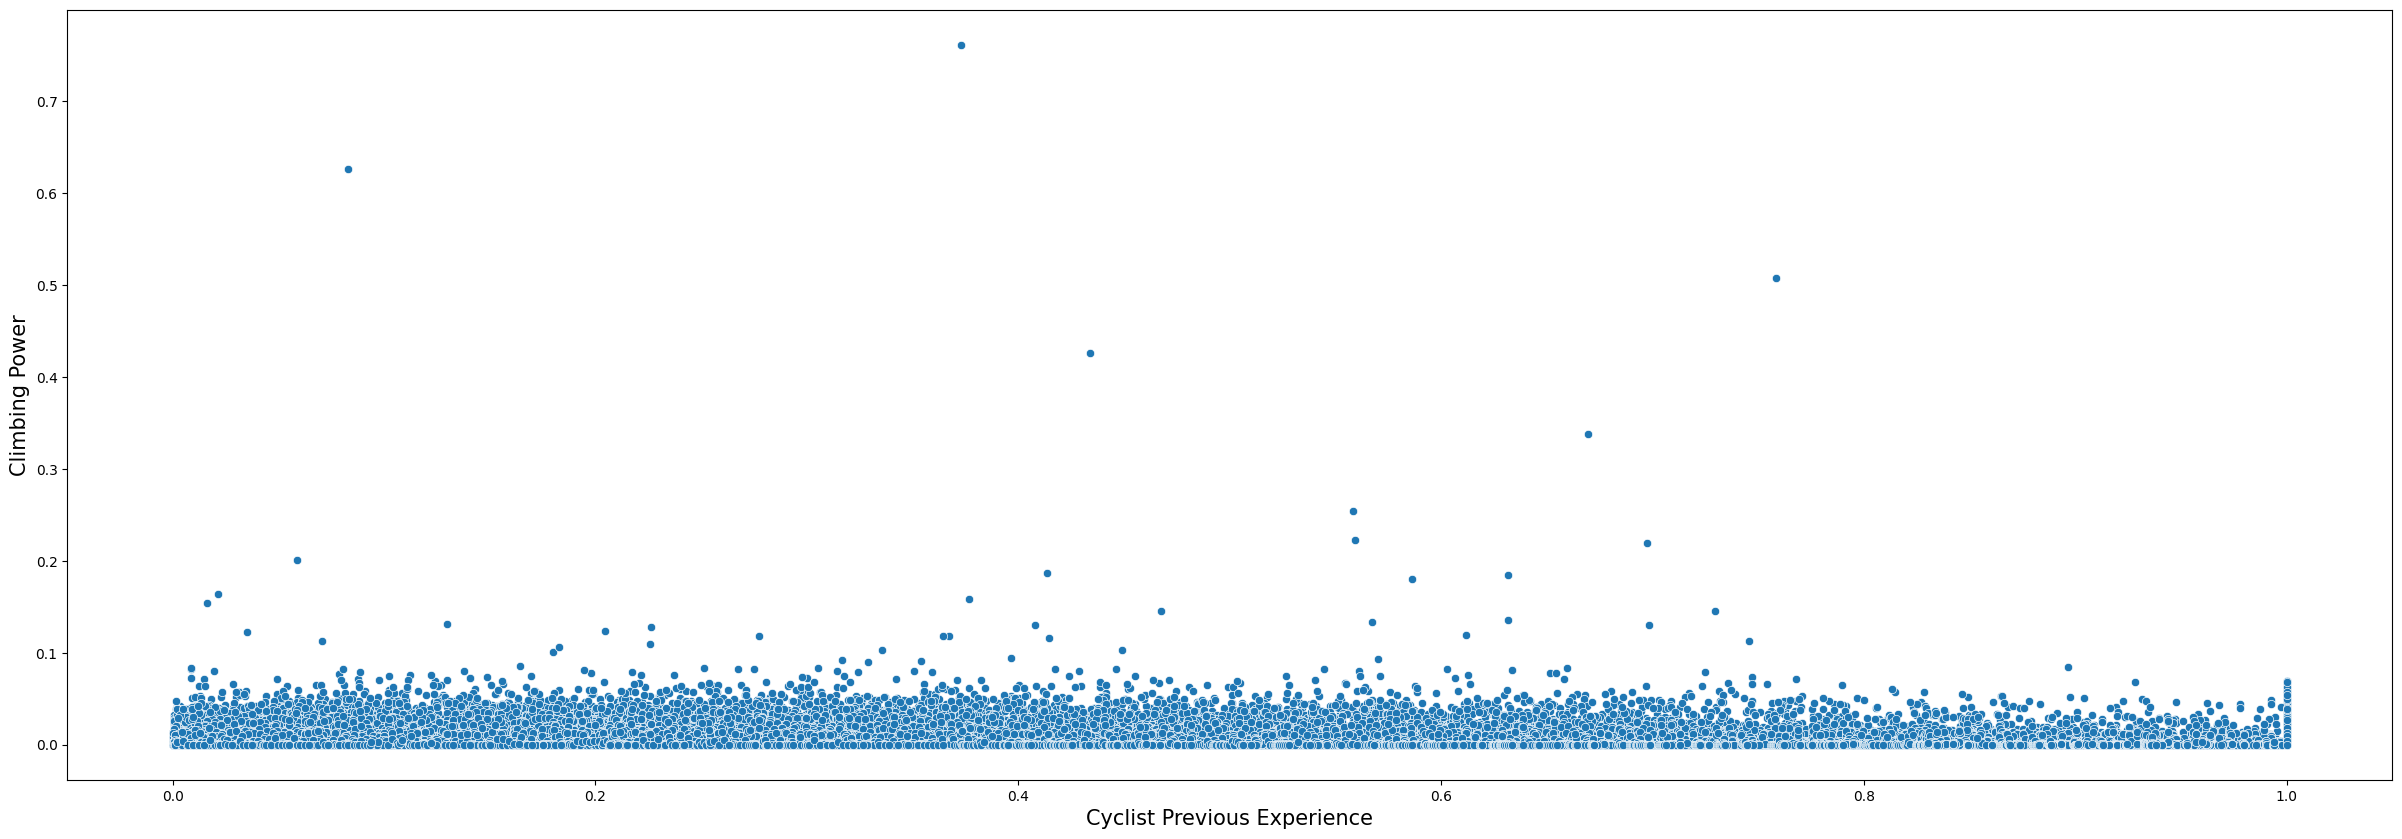

In [53]:
plt.figure(figsize=(30, 10))
sb.scatterplot(
    x='cyclist_previous_experience',
    y='cyclist_climb_power',
    data=dataset)
plt.xlabel('Cyclist Previous Experience', fontsize=15)
plt.ylabel('Climbing Power', fontsize=15)
plt.show()

From the graph, it seems that the more experience you have, the more the "climb power" tends to decrease, but this is probably a bias due to the low presence of cyclists with a lot of experience.

### Feature Correlation

In [54]:
normalized_dataset_races, normalization_scalers_races = center_and_scale(dataset)
corr_merged = correlations(normalized_dataset_races)
corr_merged

,birth_year,weight,height,points,uci_points,length,climb_total,profile,startlist_quality,position,...,race_prestige,mean_cyclist_cp,mean_delta,mean_position,previous_mean_position,previous_mean_delta,previous_mean_cp,cyclist_previous_experience,num_participants,correlation_type
birth_year,1.000000,-0.045815,0.084267,-0.188950,0.343416,-0.063052,0.045471,0.124779,-0.143592,0.005725,...,-0.156955,0.165551,0.272604,0.022847,0.047060,0.275515,-0.094036,-0.180658,0.133968,kendall
weight,-0.045815,1.000000,0.563195,0.053643,0.030793,0.032437,-0.020882,-0.032249,0.038300,0.095103,...,0.047797,-0.102569,0.280702,0.219858,0.173576,0.242428,-0.088224,-0.008157,-0.010657,kendall
height,0.084267,0.563195,1.000000,0.011802,0.058356,0.009892,-0.004051,-0.000033,0.007022,0.065440,...,0.010506,-0.059748,0.187973,0.152147,0.128401,0.171328,-0.051540,-0.026543,0.008771,kendall
points,-0.188950,0.053643,0.011802,1.000000,0.550895,0.283126,0.047106,-0.075127,0.387596,0.000005,...,0.791818,-0.115152,-0.057531,-0.020512,-0.026847,-0.048761,-0.012857,0.063004,0.078185,kendall
uci_points,0.343416,0.030793,0.058356,0.550895,1.000000,0.171325,0.062417,0.030337,0.100071,-0.000002,...,0.411640,-0.109383,0.089193,-0.018839,-0.017249,0.121946,-0.116270,0.031127,-0.037362,kendall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
previous_mean_position,0.068560,0.252472,0.186838,-0.035598,-0.023782,0.000699,-0.023565,-0.009889,-0.076786,0.460848,...,-0.051217,-0.412477,0.635920,0.867711,1.000000,0.638685,-0.531398,-0.412010,0.011312,spearman
previous_mean_delta,0.395733,0.350317,0.248058,-0.065299,0.171602,-0.019698,0.043469,0.089377,-0.062106,0.307534,...,-0.054143,-0.179547,0.836665,0.602135,0.638685,1.000000,-0.457036,-0.150861,0.084245,spearman
previous_mean_cp,-0.147410,-0.128169,-0.075381,-0.017249,-0.162306,-0.010354,0.015293,0.005845,0.092831,-0.256422,...,0.014446,0.781627,-0.441338,-0.475183,-0.531398,-0.457036,1.000000,0.371876,0.078743,spearman
cyclist_previous_experience,-0.261153,-0.011978,-0.038892,0.081840,0.042634,-0.004027,0.025796,0.024902,0.107657,-0.157443,...,0.084304,0.269857,-0.279206,-0.350978,-0.412010,-0.150861,0.371876,1.000000,-0.038025,spearman


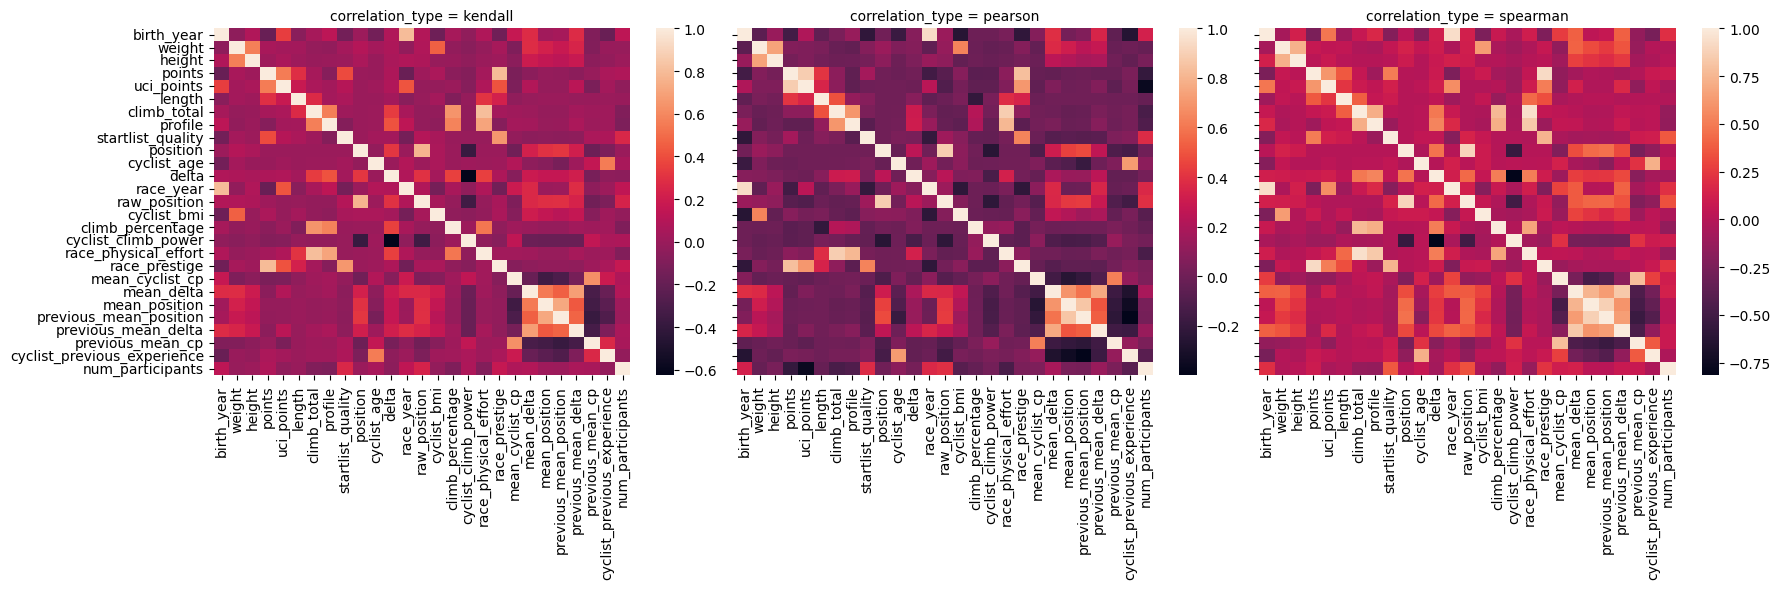

In [55]:
plt.rcParams.update({'font.size': 10})

g = sb.FacetGrid(corr_merged, col="correlation_type", height=6)
g.map_dataframe(lambda data, color: sb.heatmap(data[data.columns[:-1]]))